# MNIST MLP3 baseline comparison — zoomed diagnostics

This notebook validates and compares the persisted three-seed **SGD + Nesterov**, **AdamW**, and **Muon + auxiliary AdamW** controls. It reads only from the versioned suite directory `mnist_mlp3_recipe_v3`; old unversioned 20-epoch artifacts are ignored.

All uncertainty intervals use complete training runs as the unit of replication. Validation loss selects the reported best checkpoint; the official MNIST test set is monitoring-only.

It retains the full-range comparison plots and adds post-transient zoomed copies of the same plots. The WeightWatcher-alpha comparison also includes a second late-training view centered on the neighborhood of `alpha = 2`. All displayed DataFrames show every row and every column.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = None
for path in [Path.cwd(), *Path.cwd().parents]:
    candidate = path / 'baseline'
    if (candidate / 'rg_baselines').is_dir():
        ROOT = candidate
        break
    if (path / 'rg_baselines').is_dir():
        ROOT = path
        break
if ROOT is None:
    raise RuntimeError('Run from a current clone of CalculatedContent/rg_optimizers.')
ROOT = ROOT.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from rg_baselines import (
    MNIST_REFERENCE_INITIALIZATION,
    MNIST_REFERENCE_RECIPE_VERSION,
    MNIST_REFERENCE_SUITE_SLUG,
)
from rg_baselines.comparison import (
    LAYER_ORDER,
    OPTIMIZER_COLORS,
    OPTIMIZER_LABELS,
    OPTIMIZER_ORDER,
    run_baseline_comparison,
)
from rg_baselines.comparison_plotting import (
    PERFORMANCE_PLOTS,
    SPECTRAL_PLOTS,
    plot_performance_metric,
    plot_spectral_metric,
)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

BASE_RUN_ROOT = Path(
    os.environ.get('RG_BASELINE_RUN_ROOT', ROOT / 'runs')
).expanduser().resolve()
RUN_ROOT = BASE_RUN_ROOT / MNIST_REFERENCE_SUITE_SLUG
OUTPUT_DIR = RUN_ROOT / 'comparison'

legacy_directories = [
    BASE_RUN_ROOT / optimizer
    for optimizer in OPTIMIZER_ORDER
    if (BASE_RUN_ROOT / optimizer).is_dir()
]
if legacy_directories:
    print('Ignoring legacy unversioned result directories:')
    for directory in legacy_directories:
        print('  -', directory)

required_manifests = [
    RUN_ROOT / optimizer / 'replicate_manifest.json'
    for optimizer in OPTIMIZER_ORDER
]
missing = [path for path in required_manifests if not path.is_file()]
if missing:
    raise FileNotFoundError(
        'The current recipe-v3 baseline suite is incomplete. Run these '
        'three source notebooks first, in order:\n'
        '  1. MNIST_MLP3_SGD_Momentum_Baseline.ipynb\n'
        '  2. MNIST_MLP3_AdamW_Baseline.ipynb\n'
        '  3. MNIST_MLP3_SGD_Momentum_Muon_Baseline.ipynb\n'
        'Missing manifests:\n' + '\n'.join(f'  - {path}' for path in missing)
    )

print('MNIST reference recipe:', MNIST_REFERENCE_RECIPE_VERSION)
print('versioned suite root:', RUN_ROOT)


MNIST reference recipe: 3
versioned suite root: /private/tmp/rg_optimizers/baseline/notebooks/runs/mnist_mlp3_recipe_v3


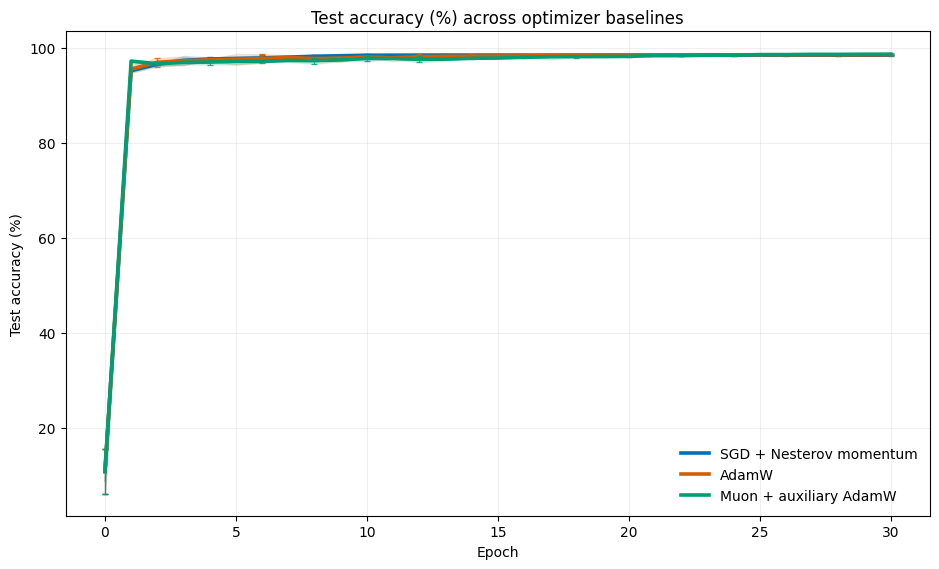

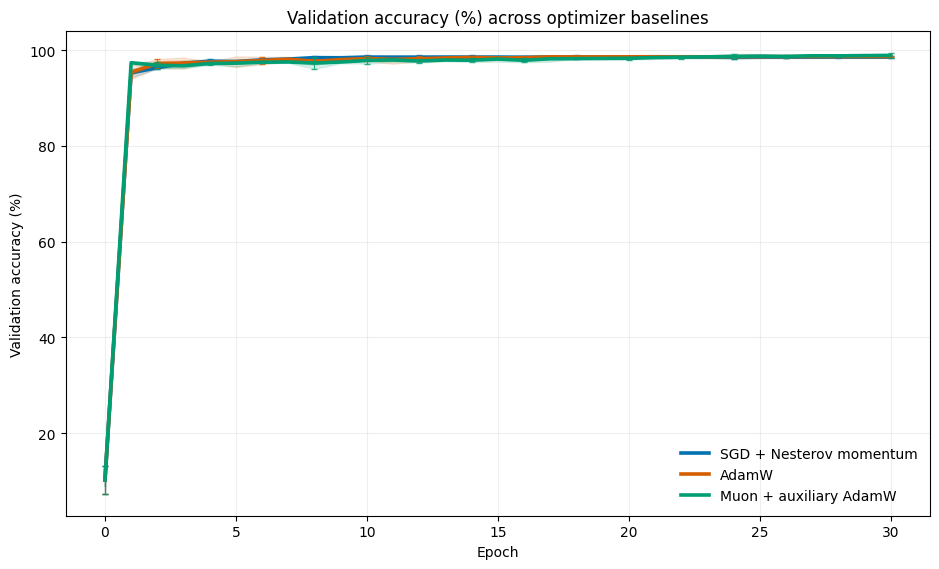

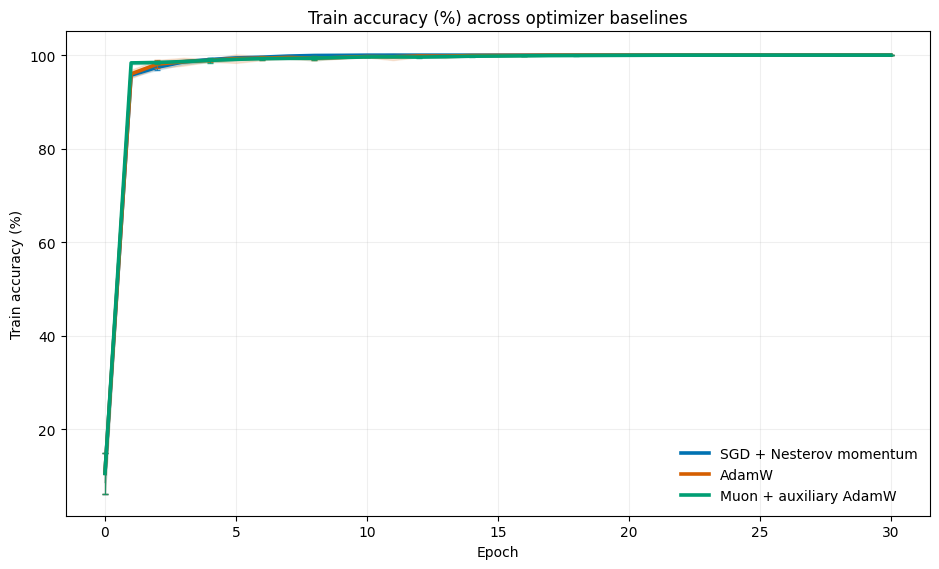

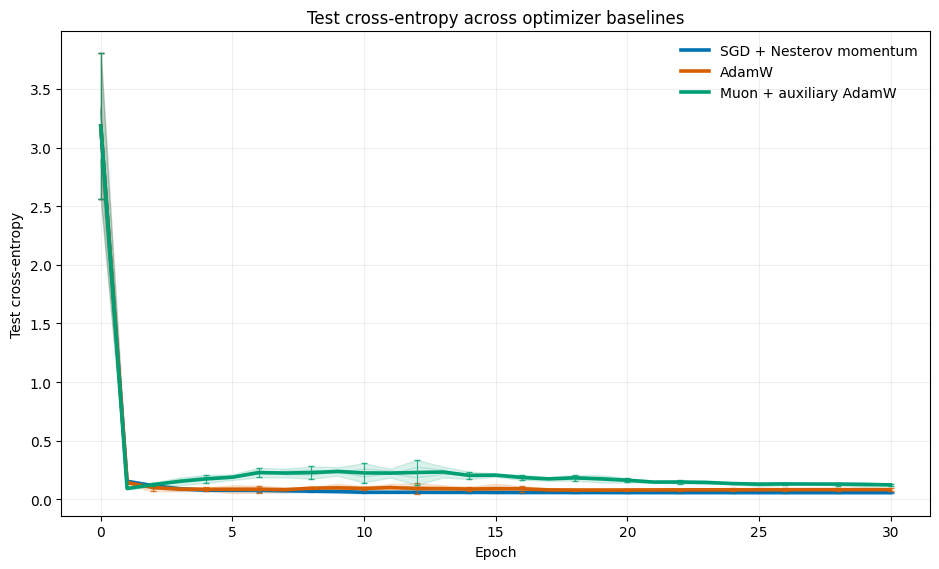

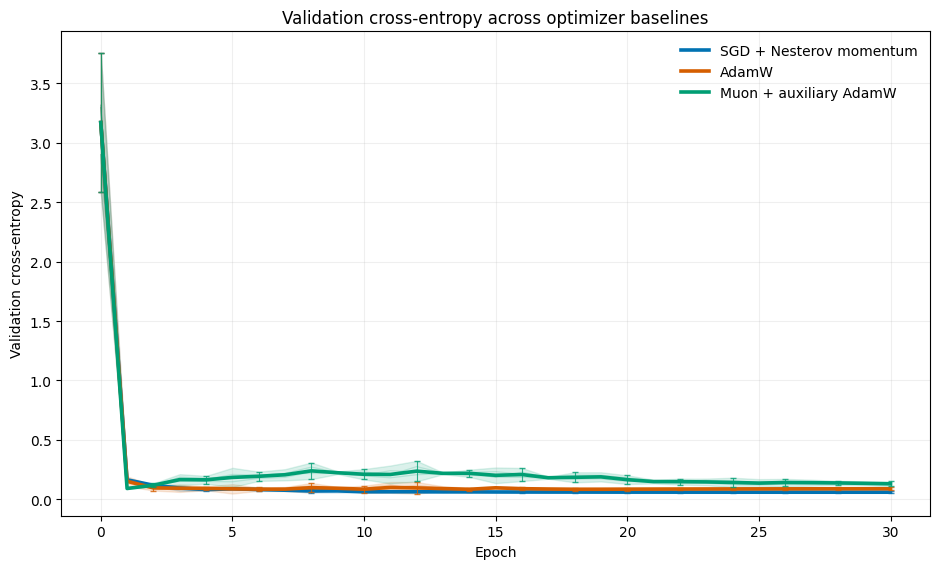

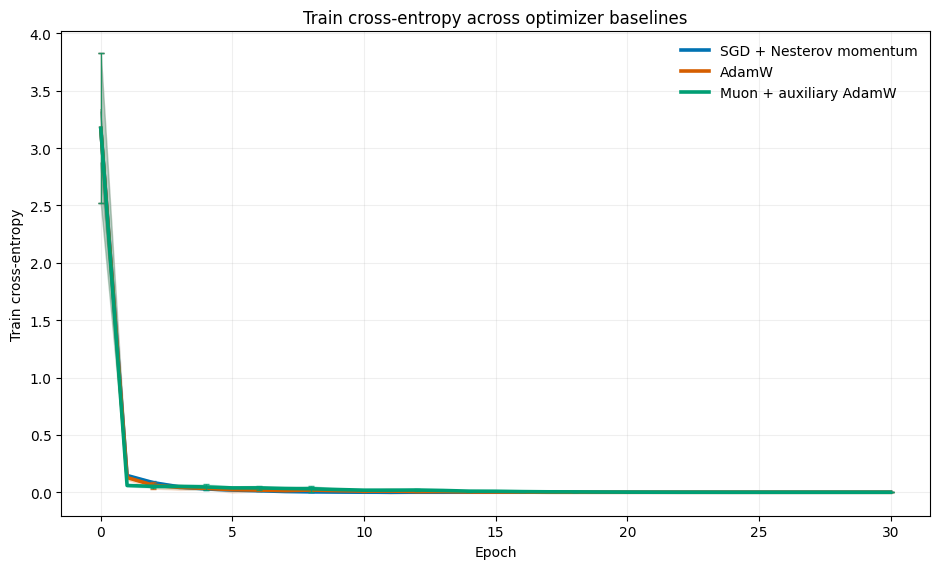

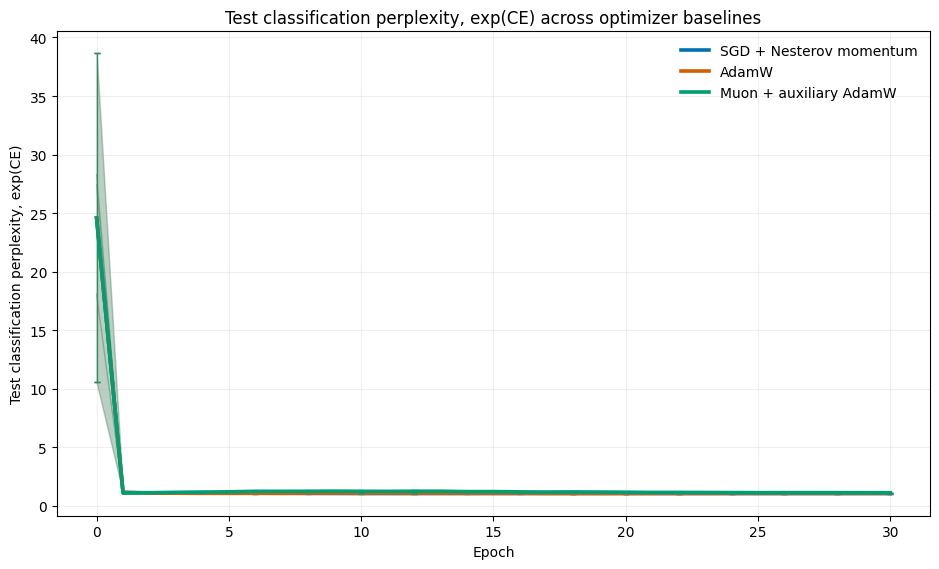

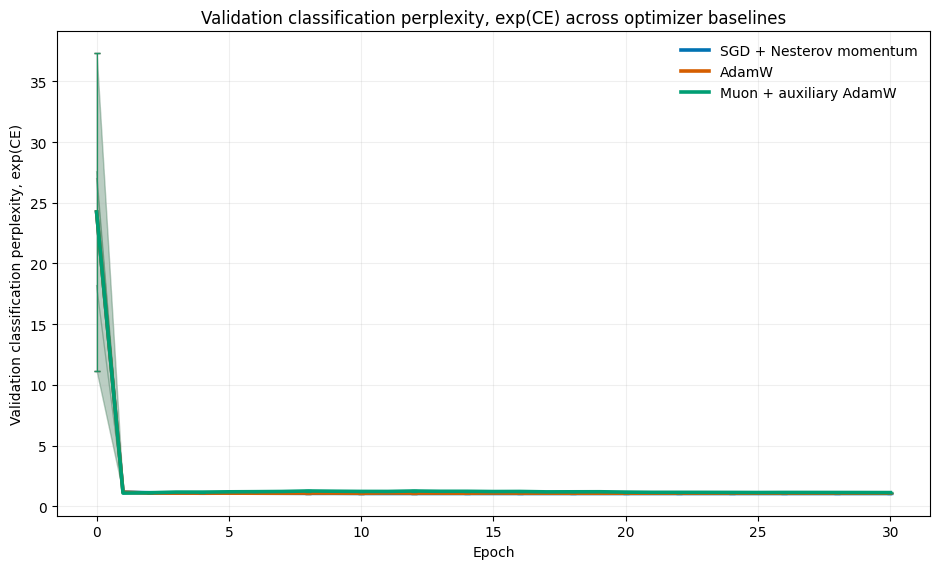

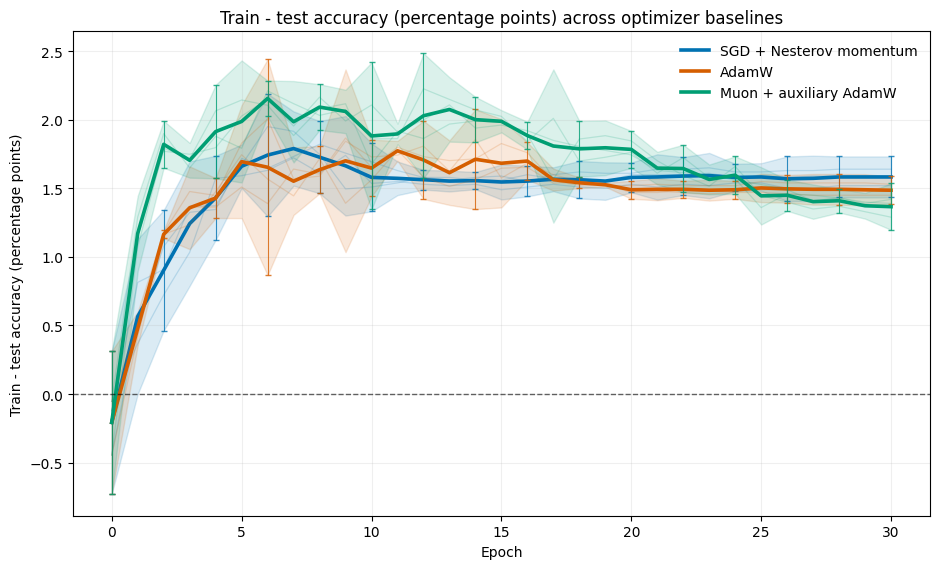

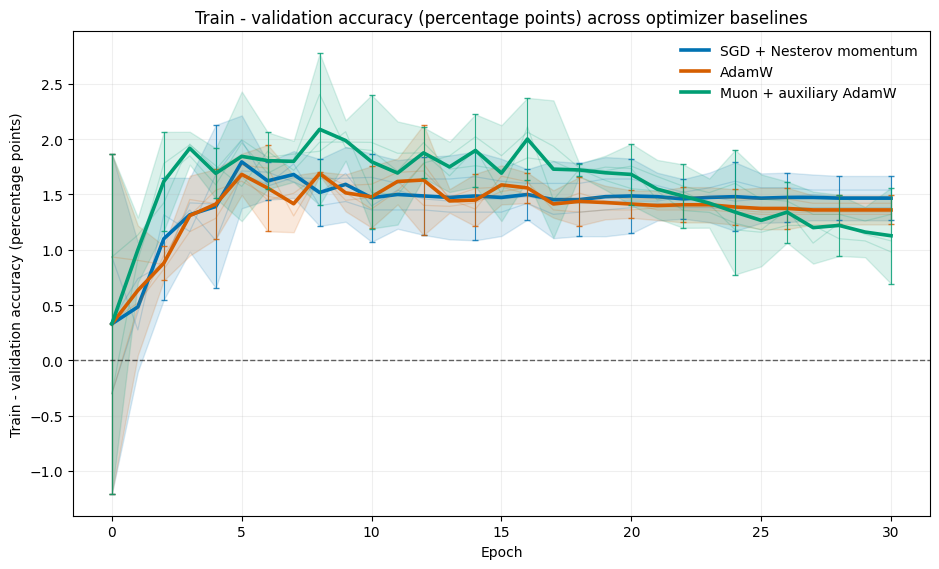

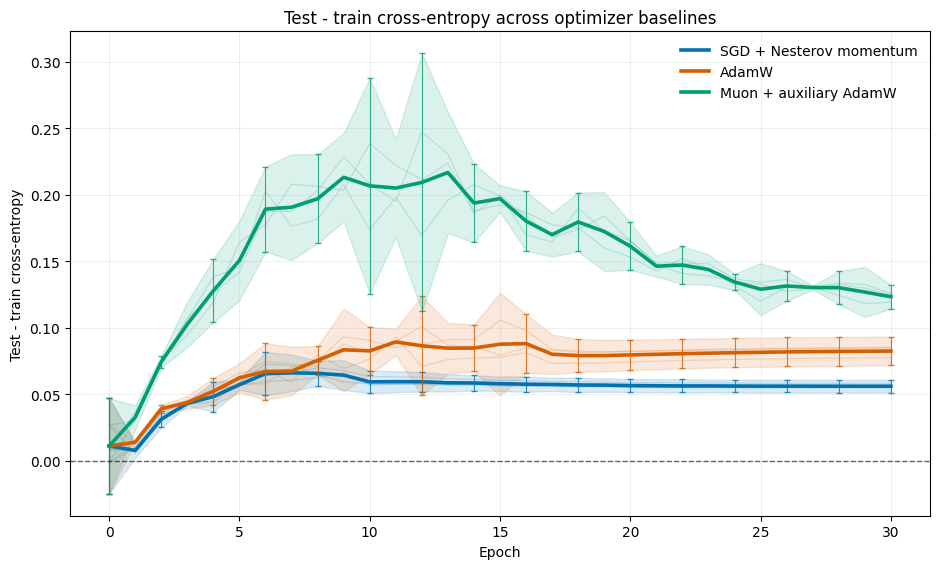

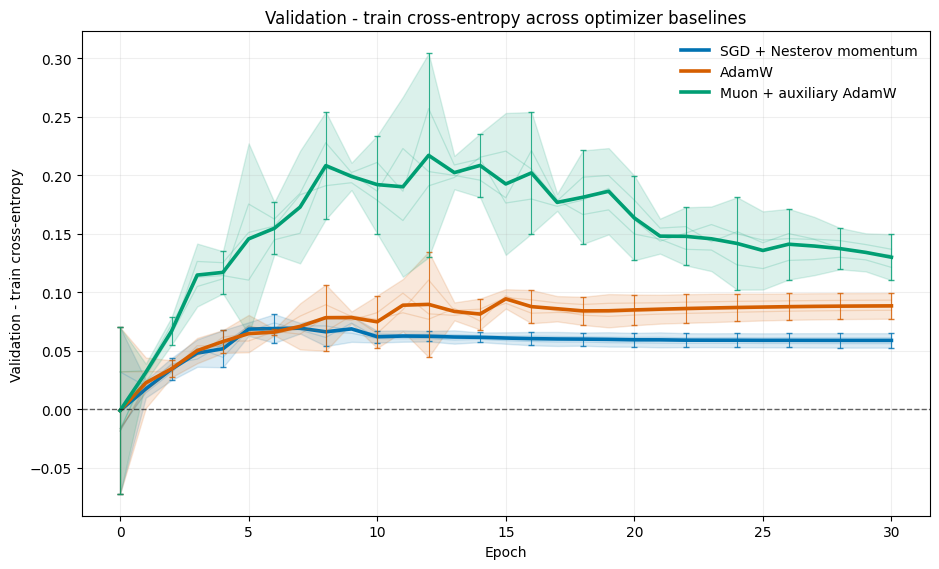

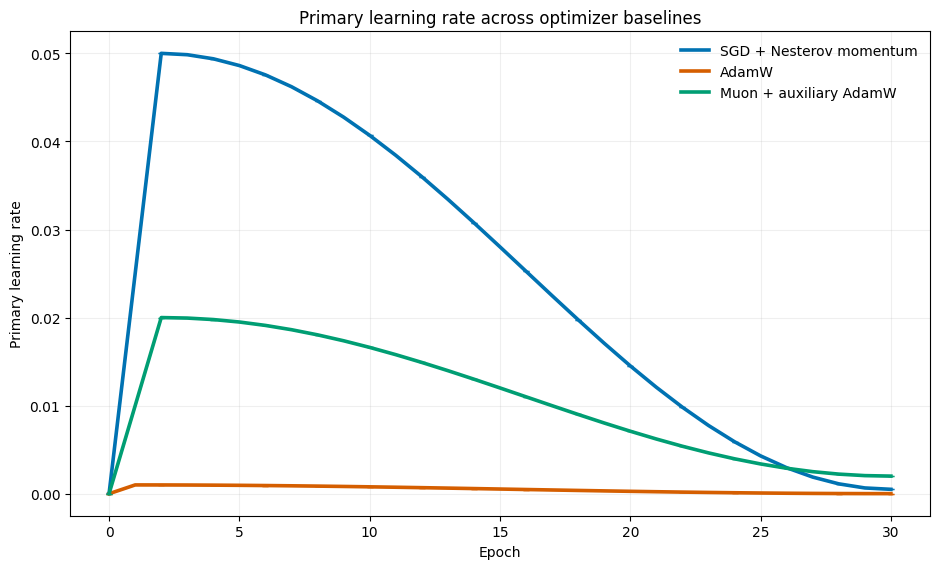

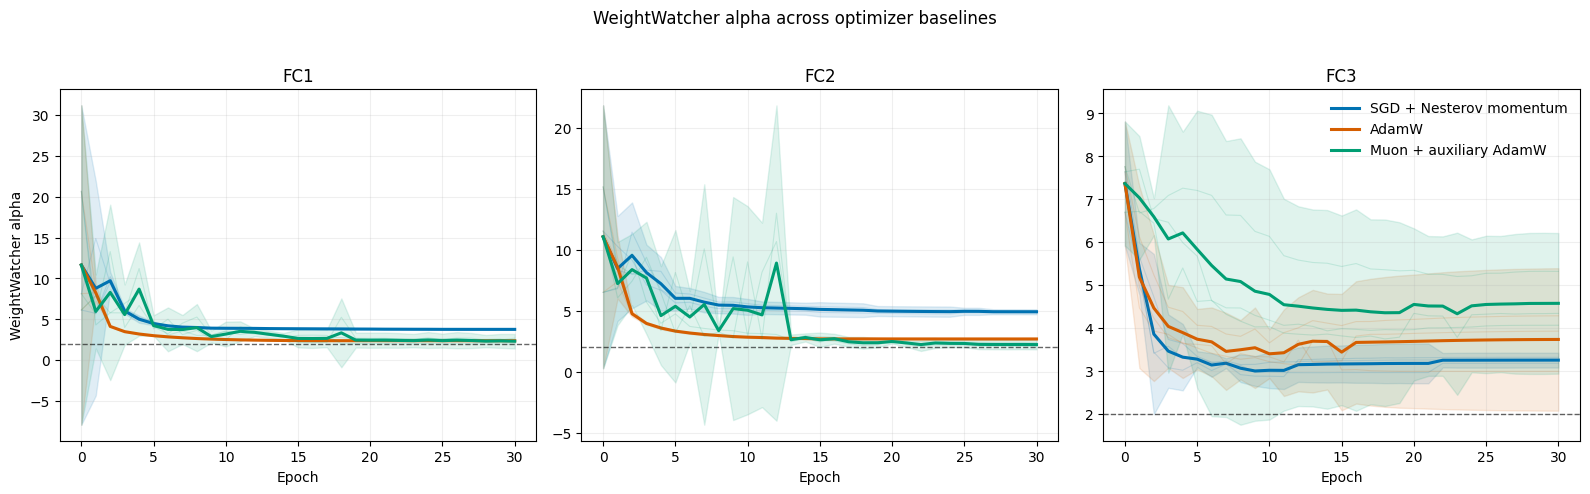

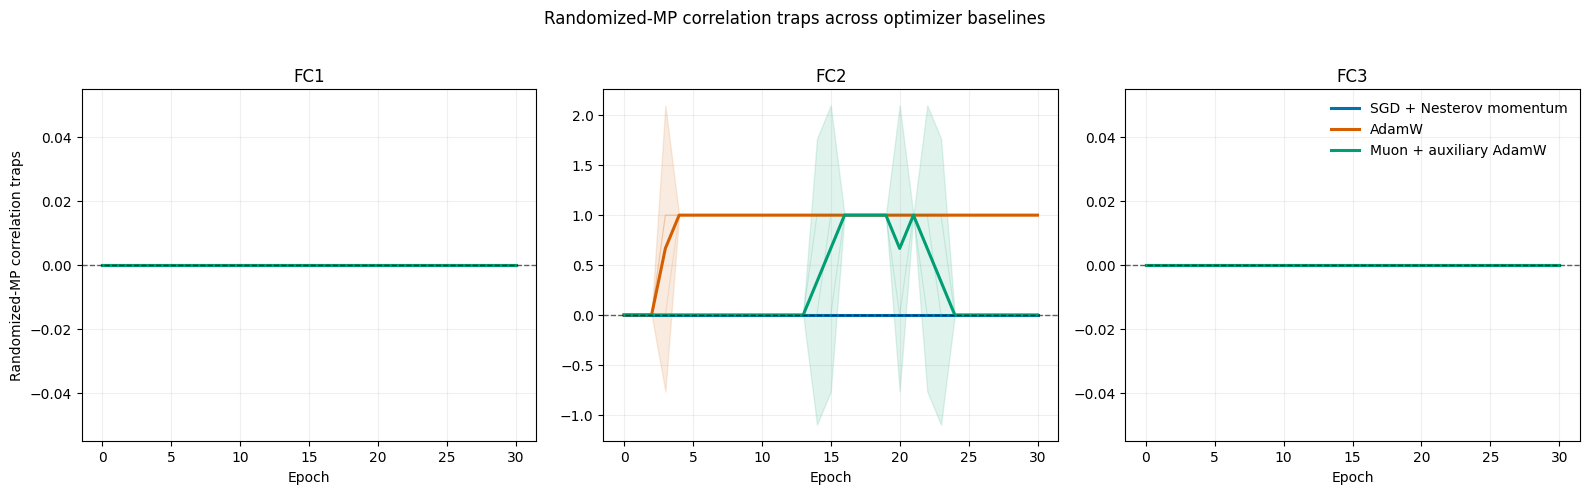

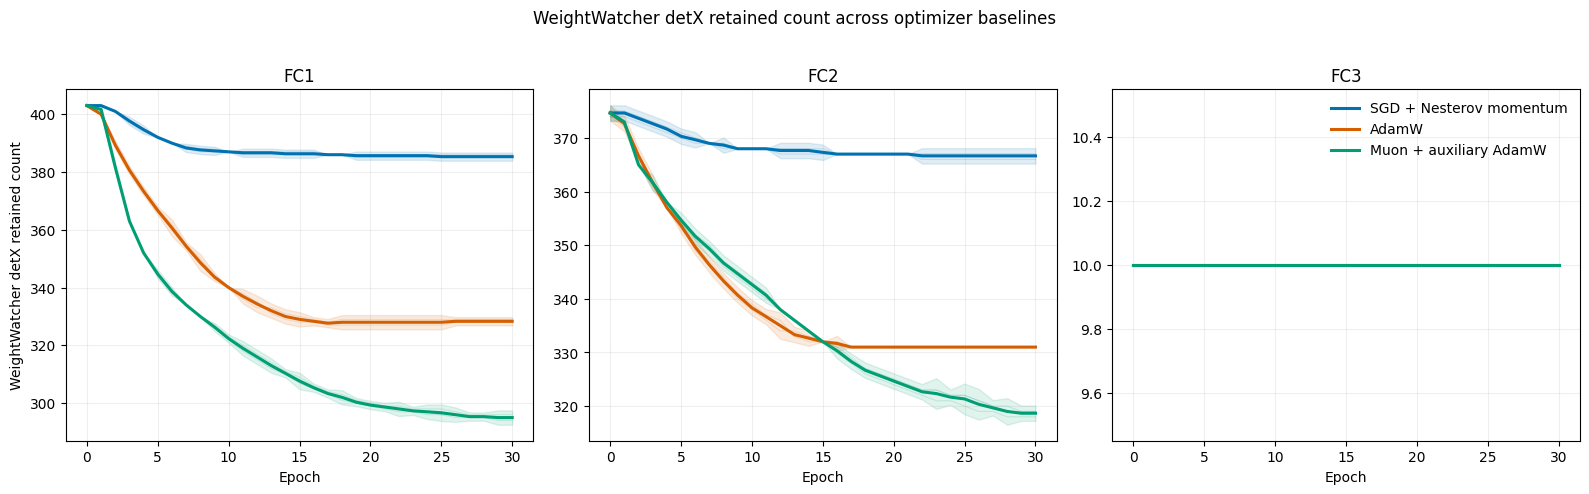

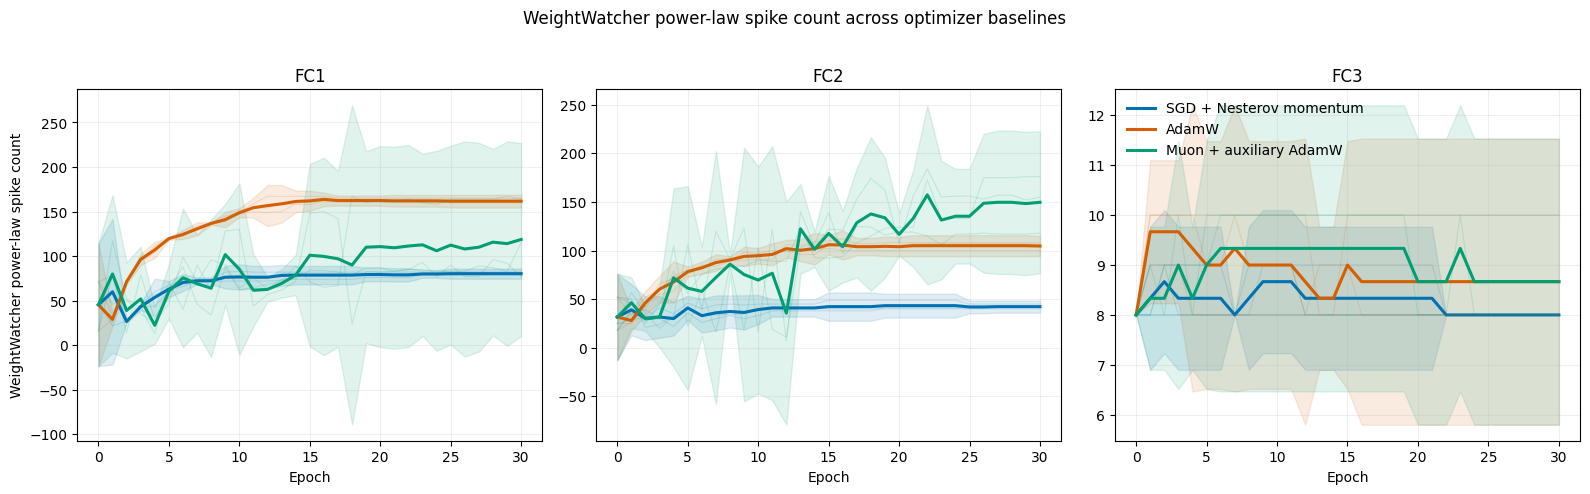

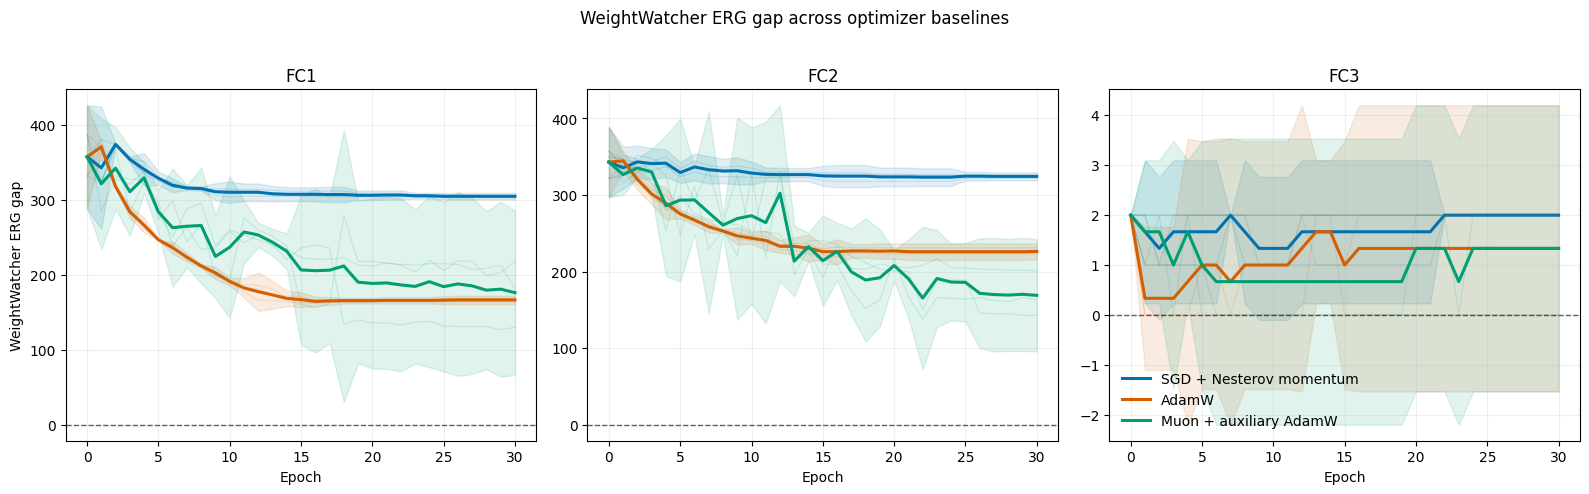

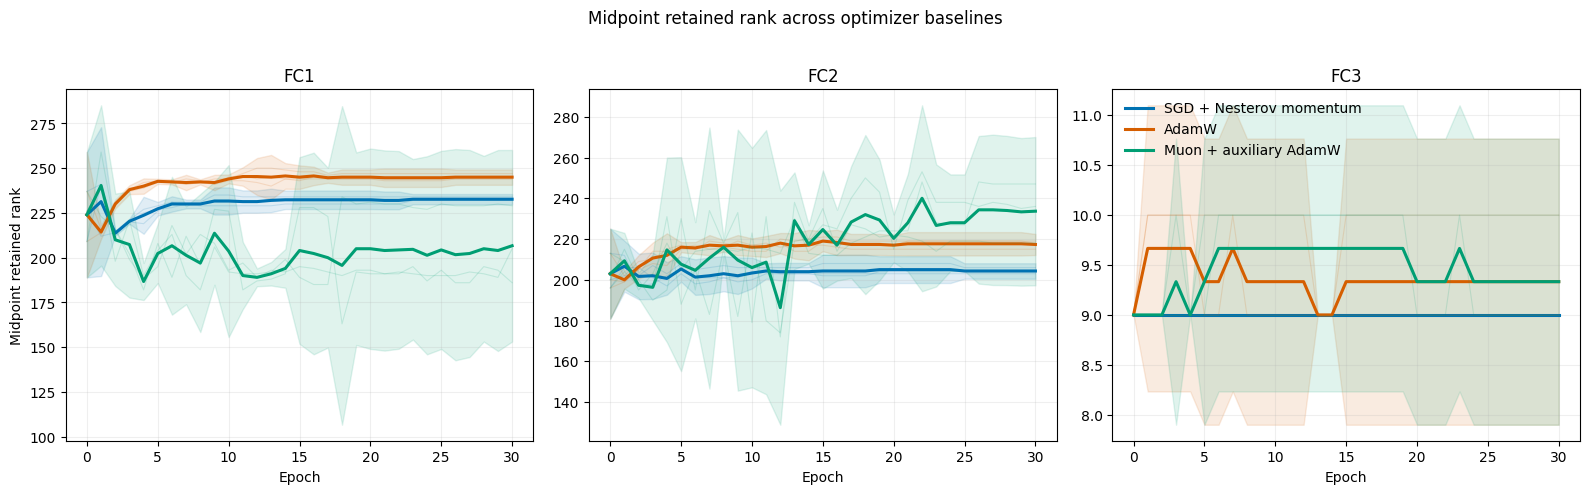

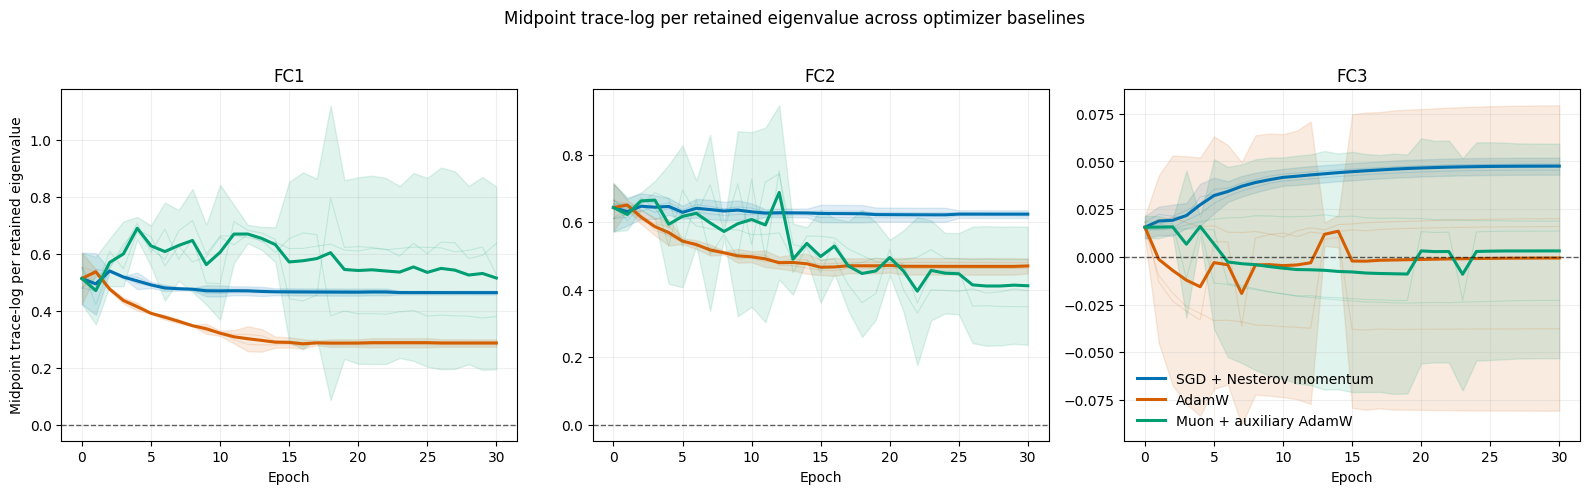

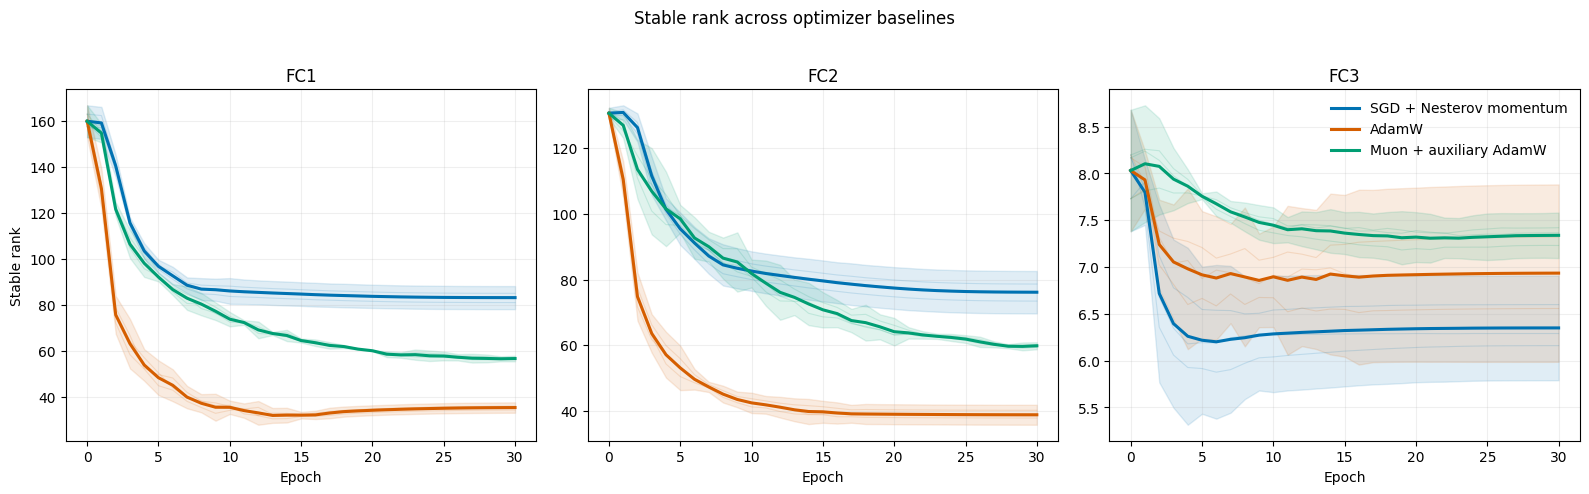

comparison outputs: /private/tmp/rg_optimizers/baseline/notebooks/runs/mnist_mlp3_recipe_v3/comparison


In [2]:
result = run_baseline_comparison(
    RUN_ROOT,
    output_dir=OUTPUT_DIR,
    show_plots=True,
)
assert len(result.seeds) == 3
assert result.epochs == 30
for optimizer, manifest in result.manifests.items():
    config = manifest['config_template']
    assert config['recipe_version'] == MNIST_REFERENCE_RECIPE_VERSION
    assert config['initialization'] == MNIST_REFERENCE_INITIALIZATION
print('comparison outputs:', OUTPUT_DIR)


## Post-transient zoomed comparison plots

The original full-range plots above remain unchanged. The additional plot suite below starts at epoch 3, omitting initialization and the first two training epochs so the later variation is visible. The two alpha figures use explicitly bounded axes; confidence bands and seed trajectories outside a displayed bound are intentionally clipped in the zoomed view, while remaining visible in the original full-range figure.


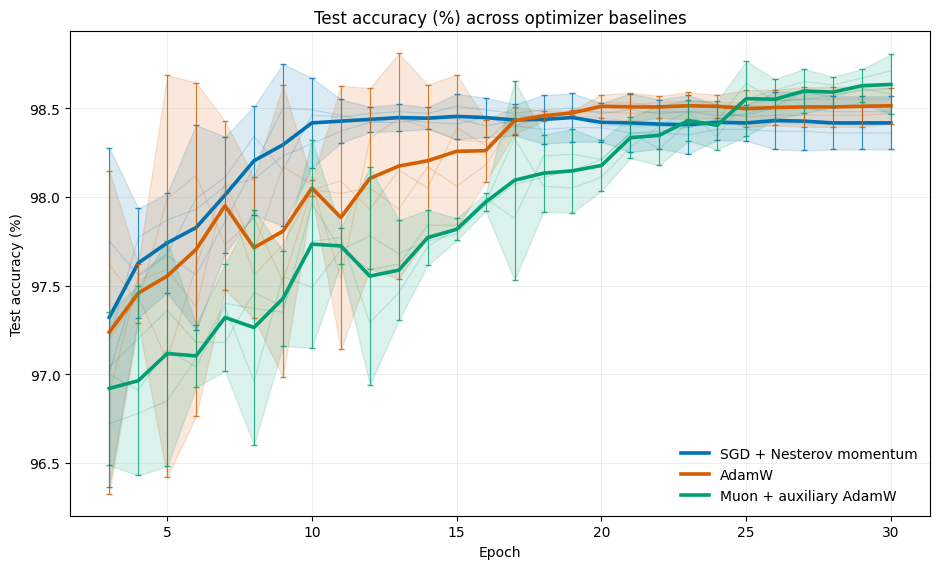

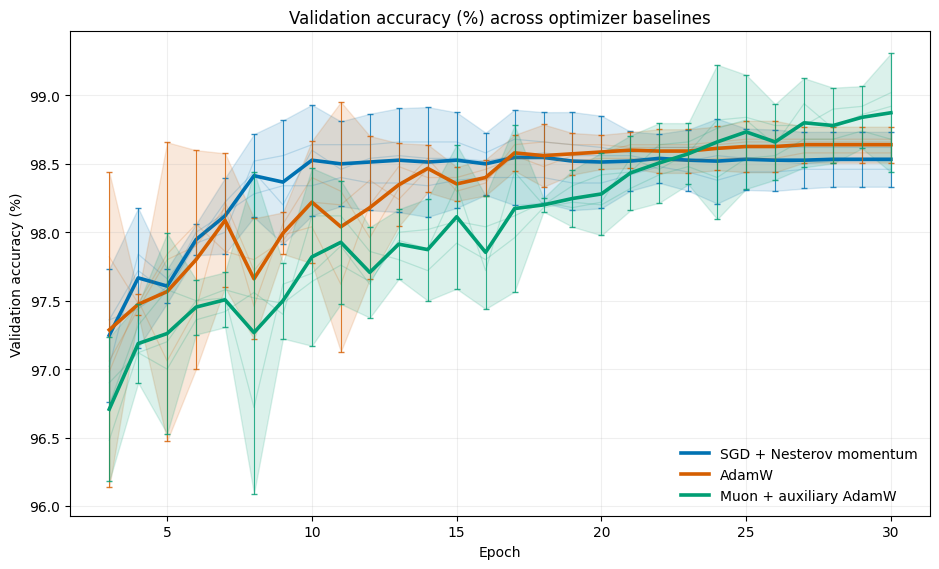

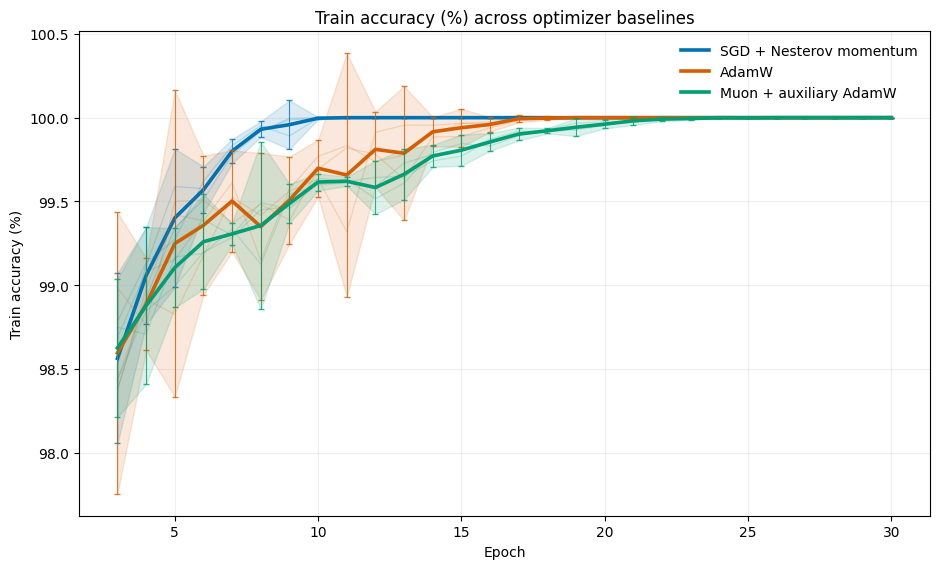

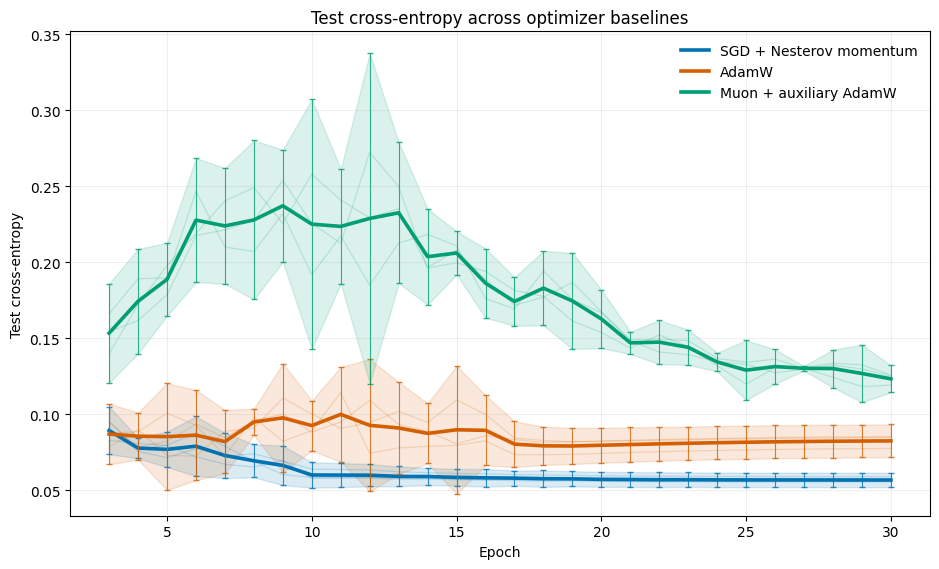

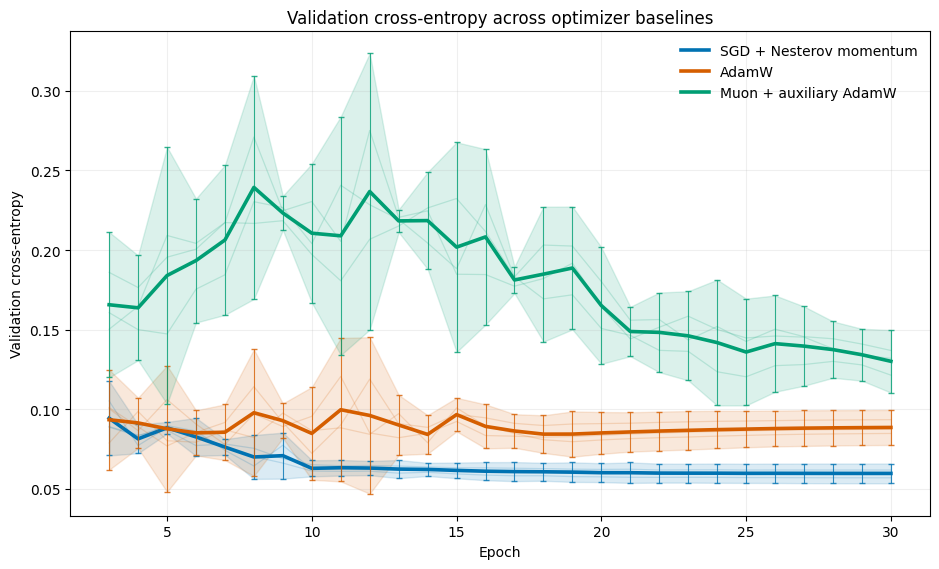

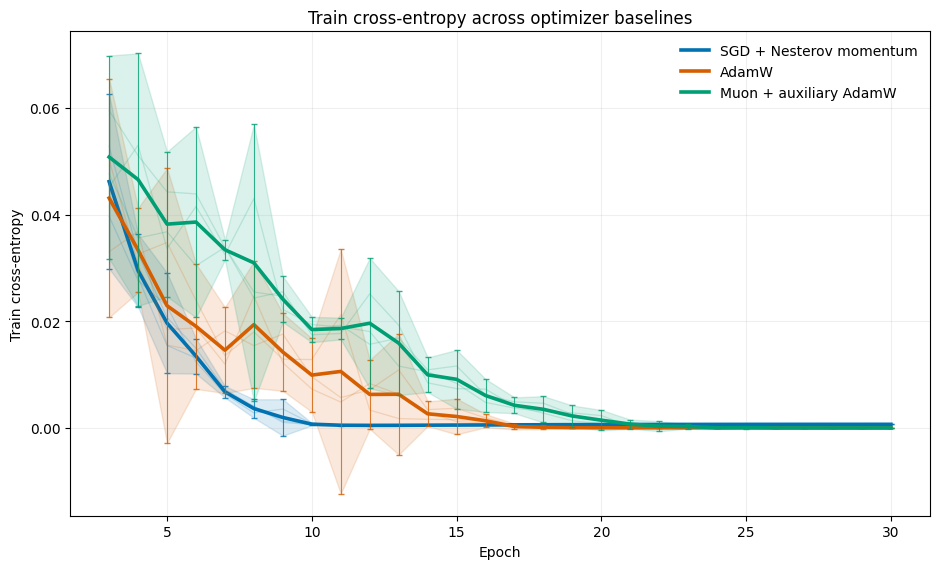

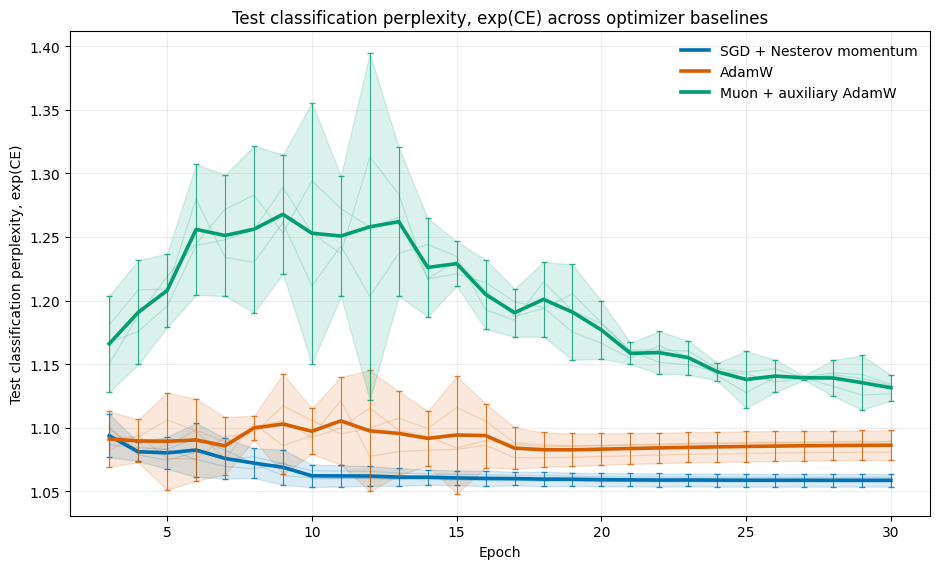

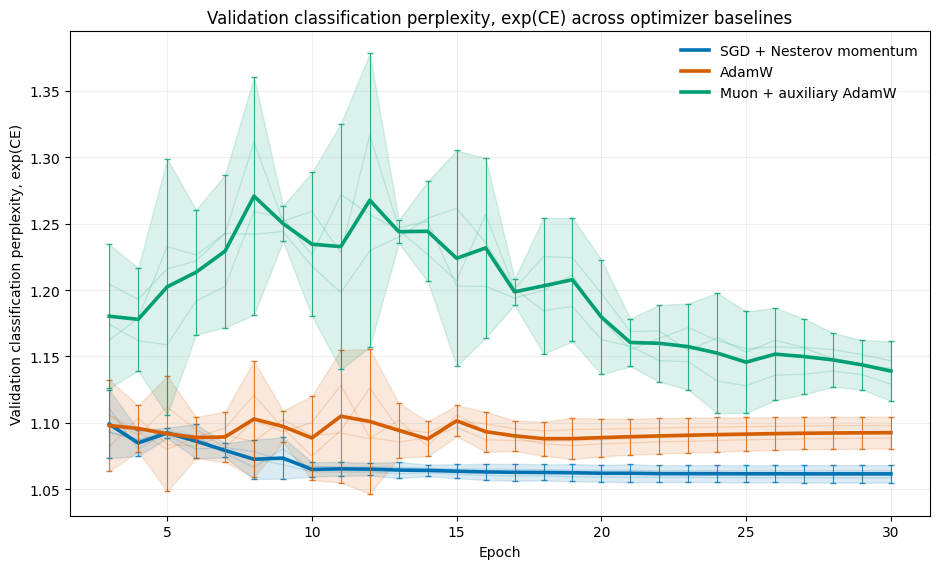

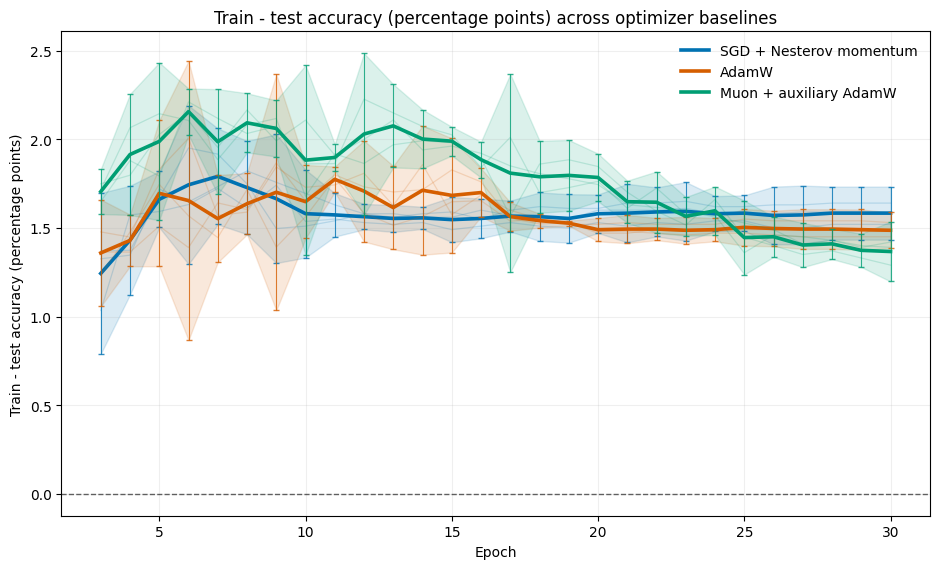

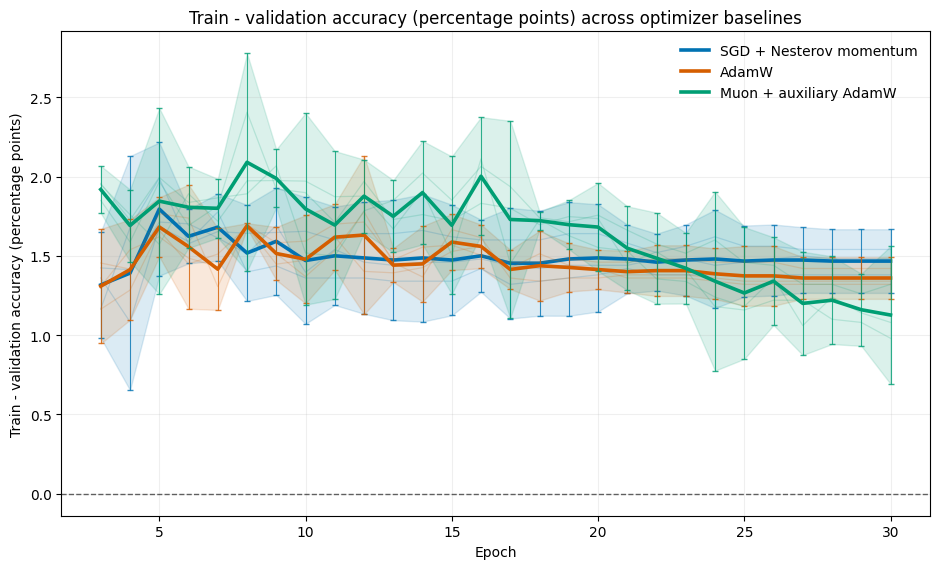

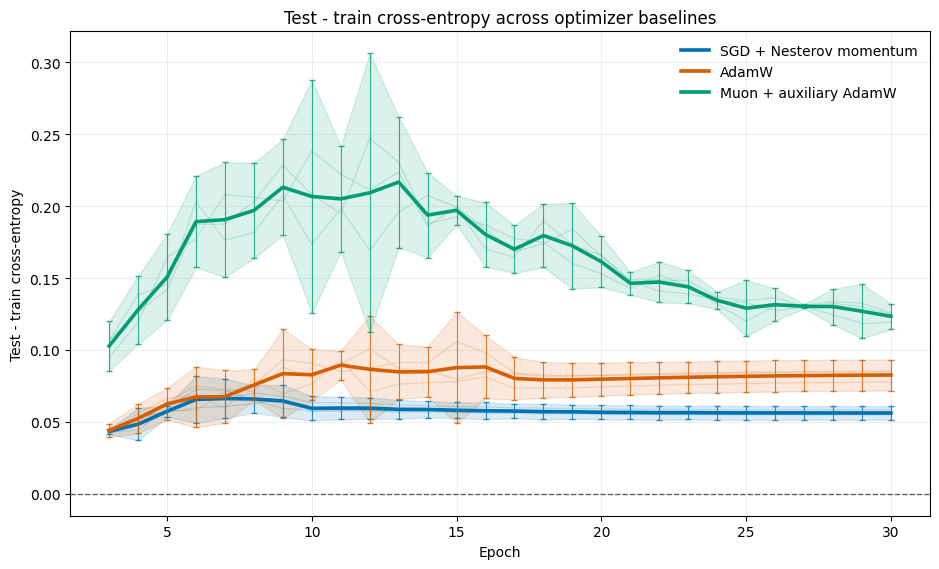

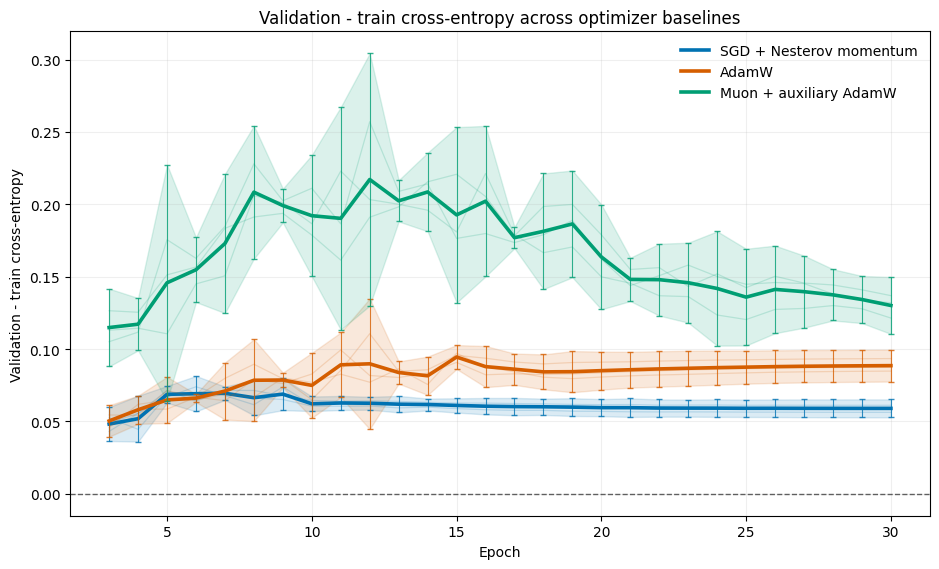

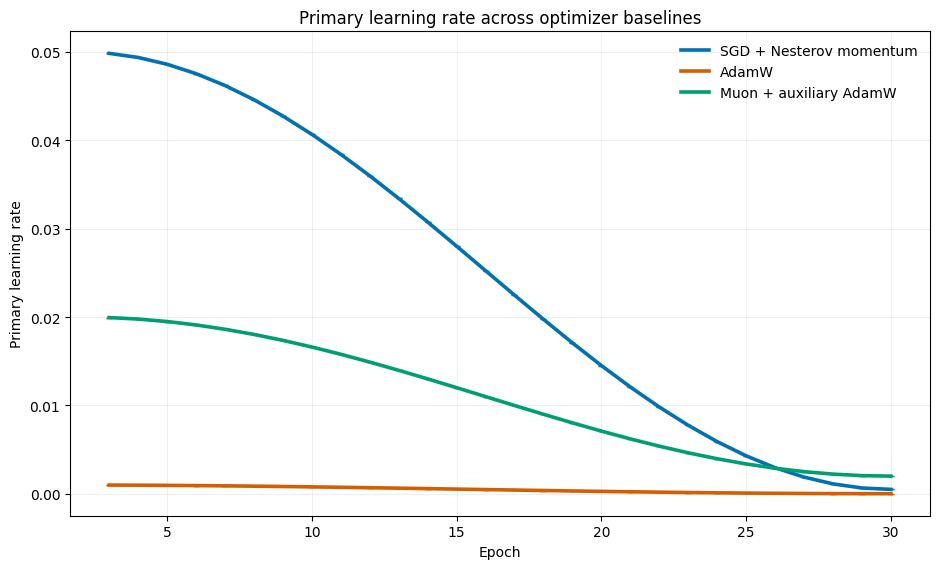

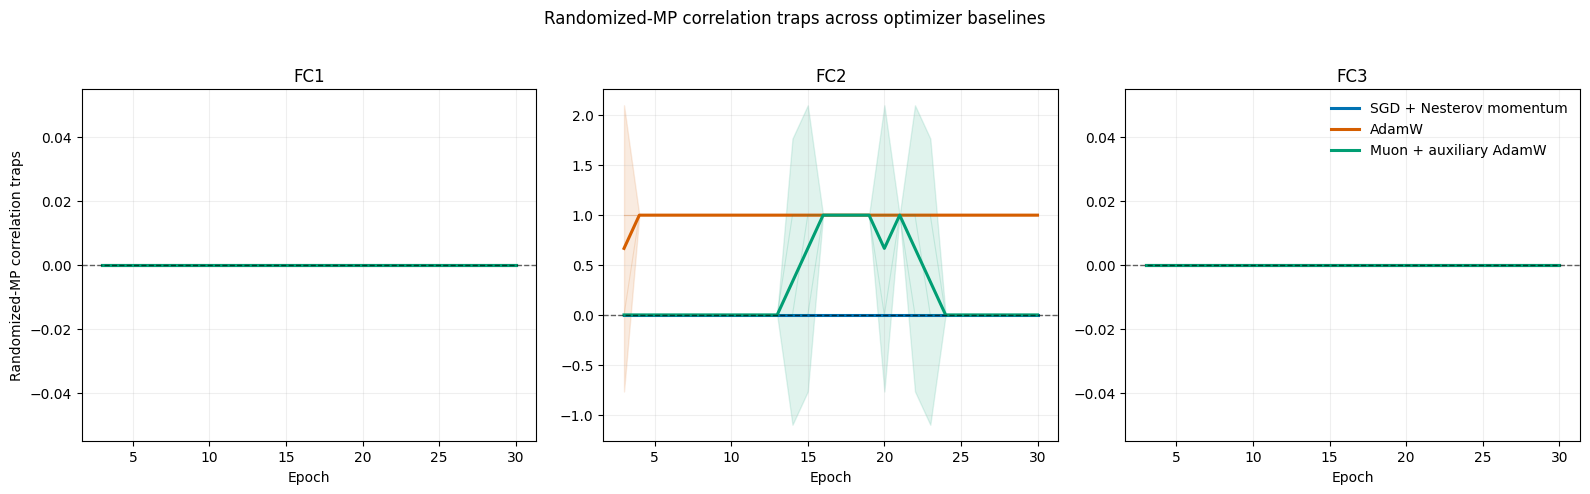

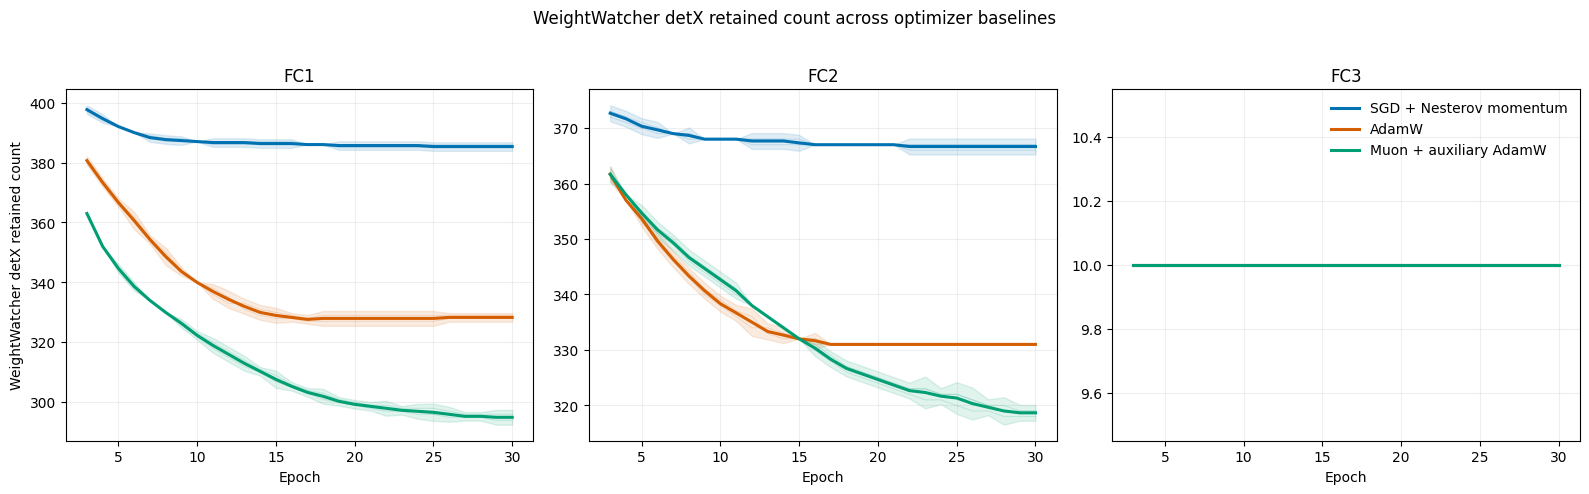

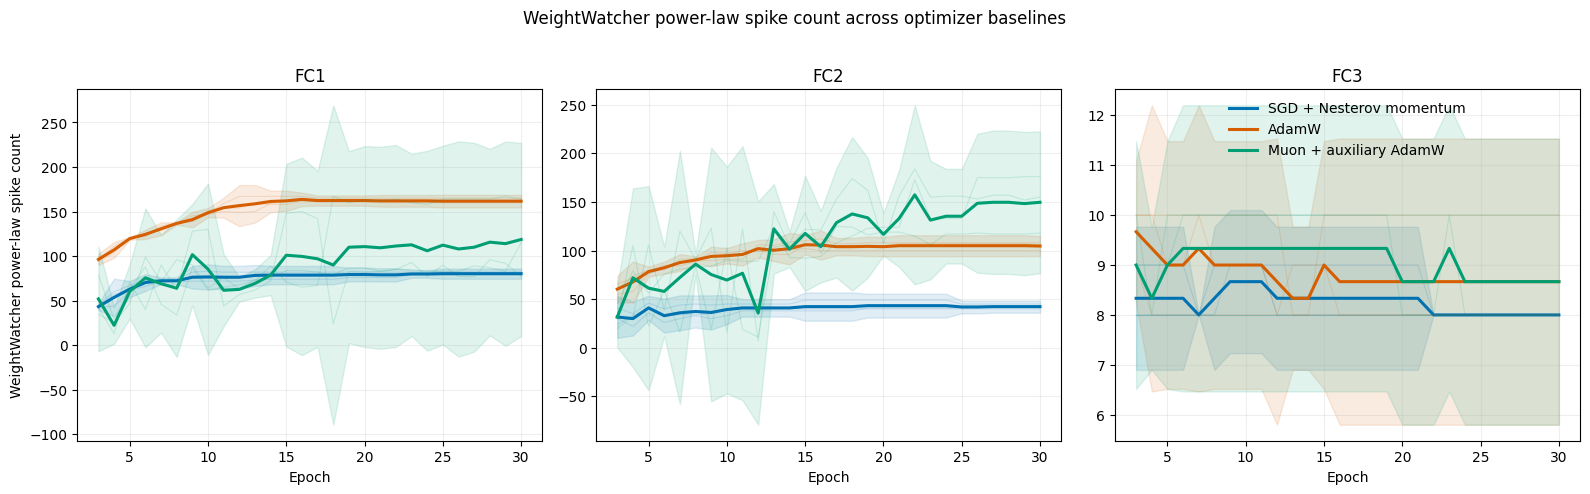

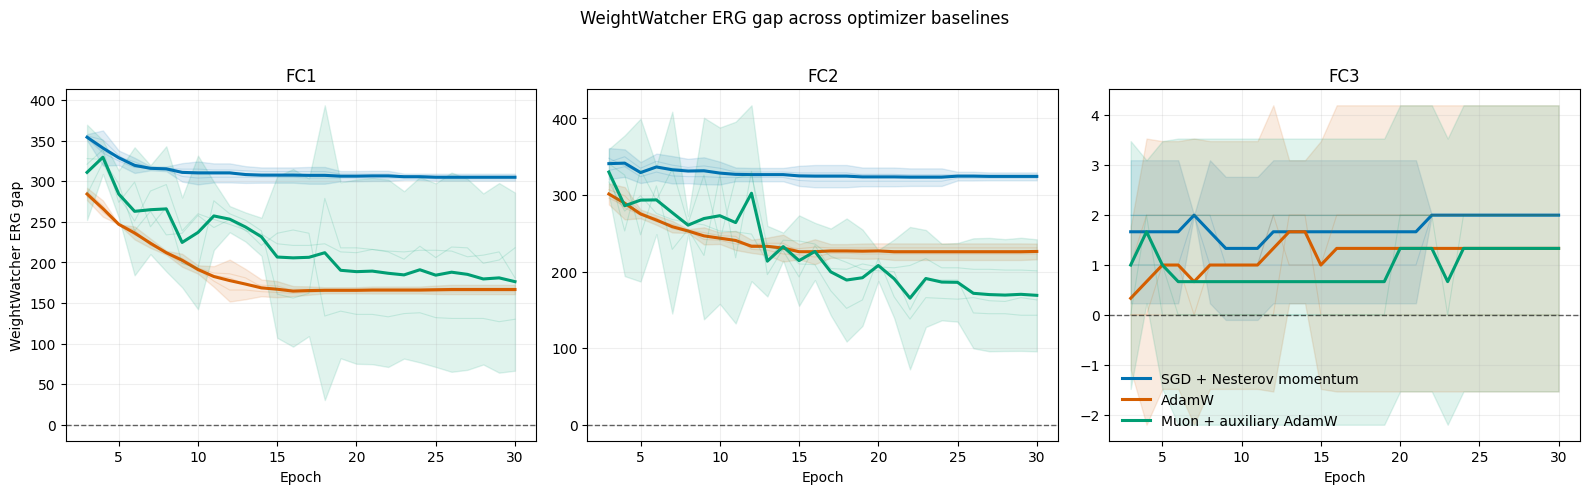

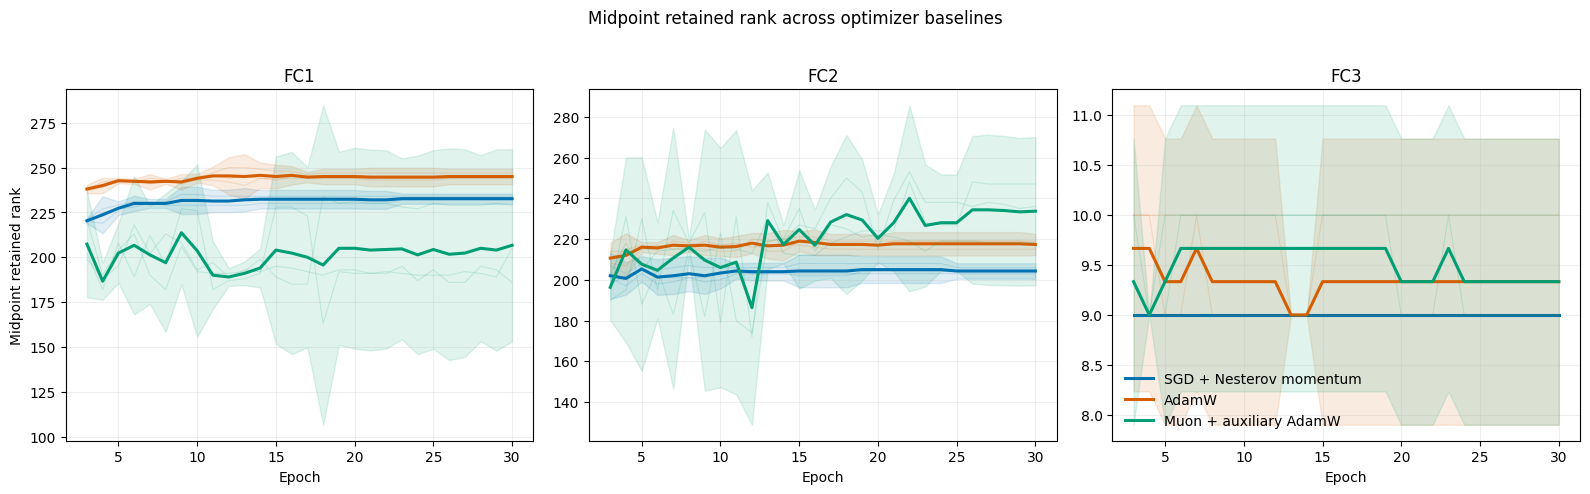

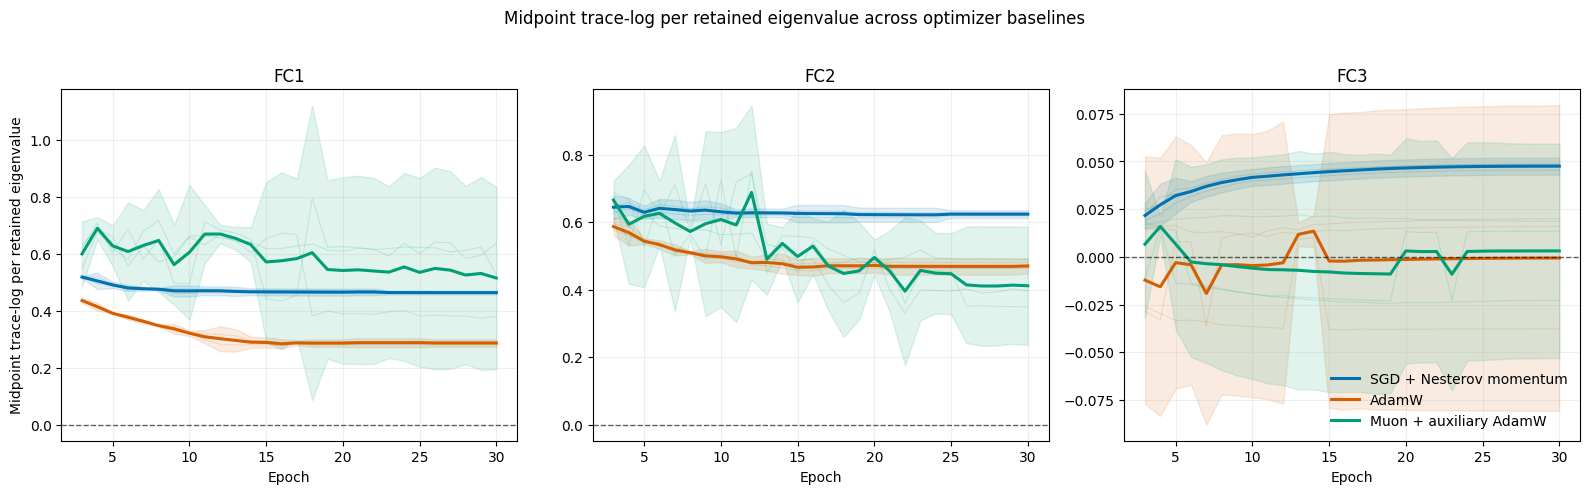

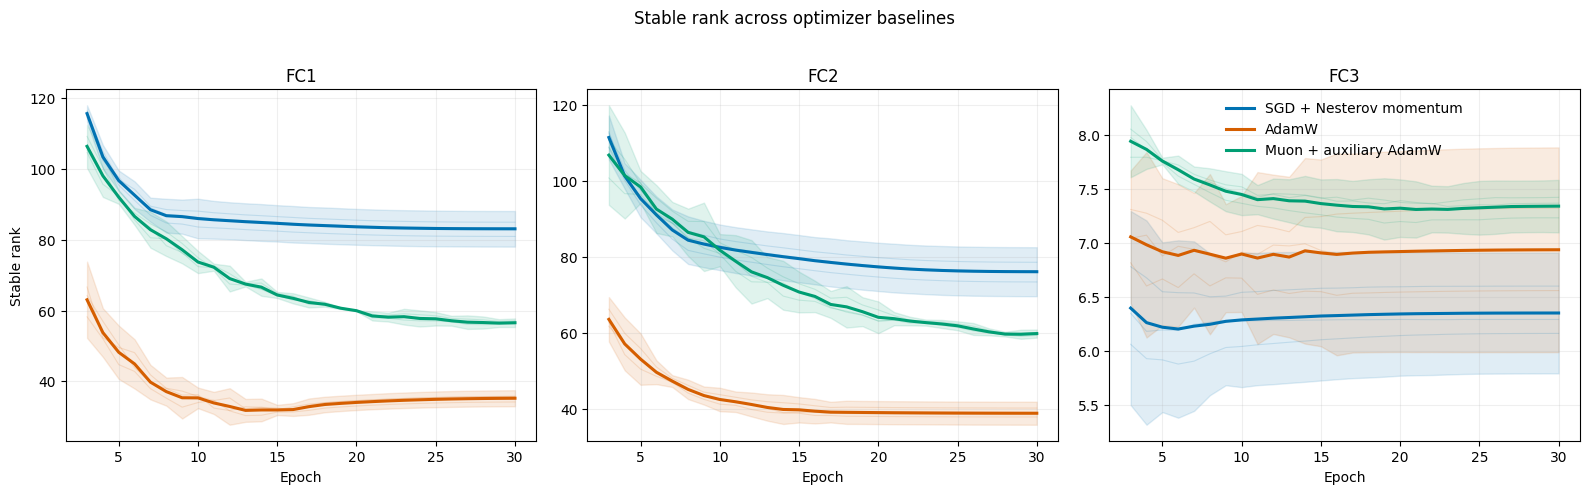

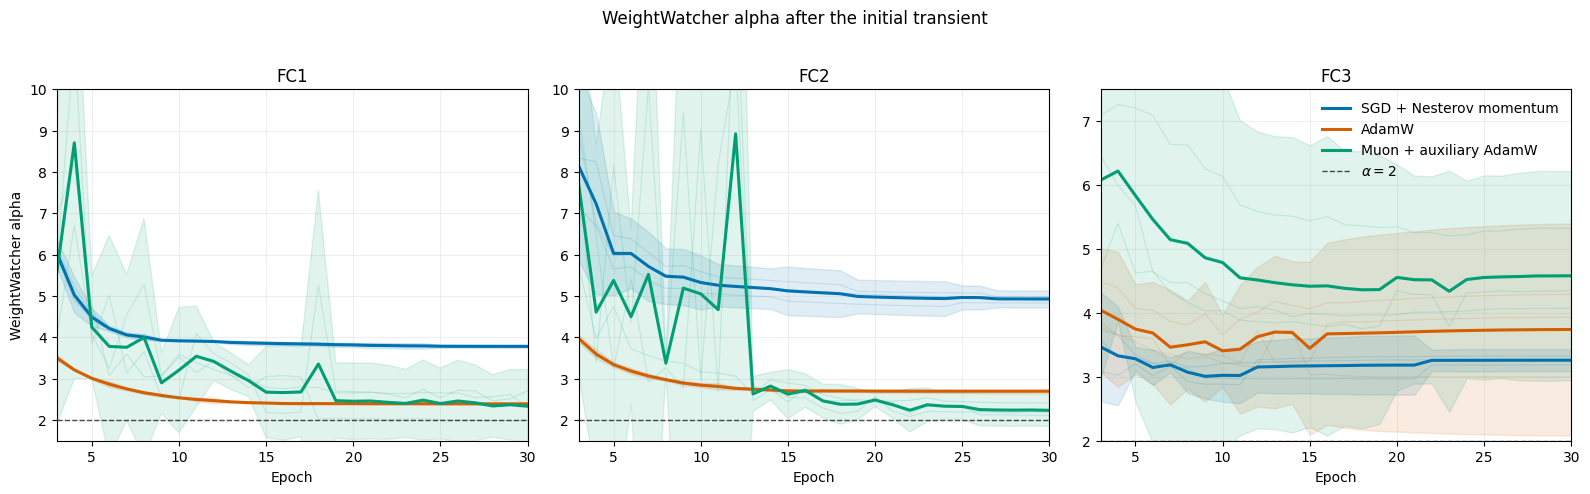

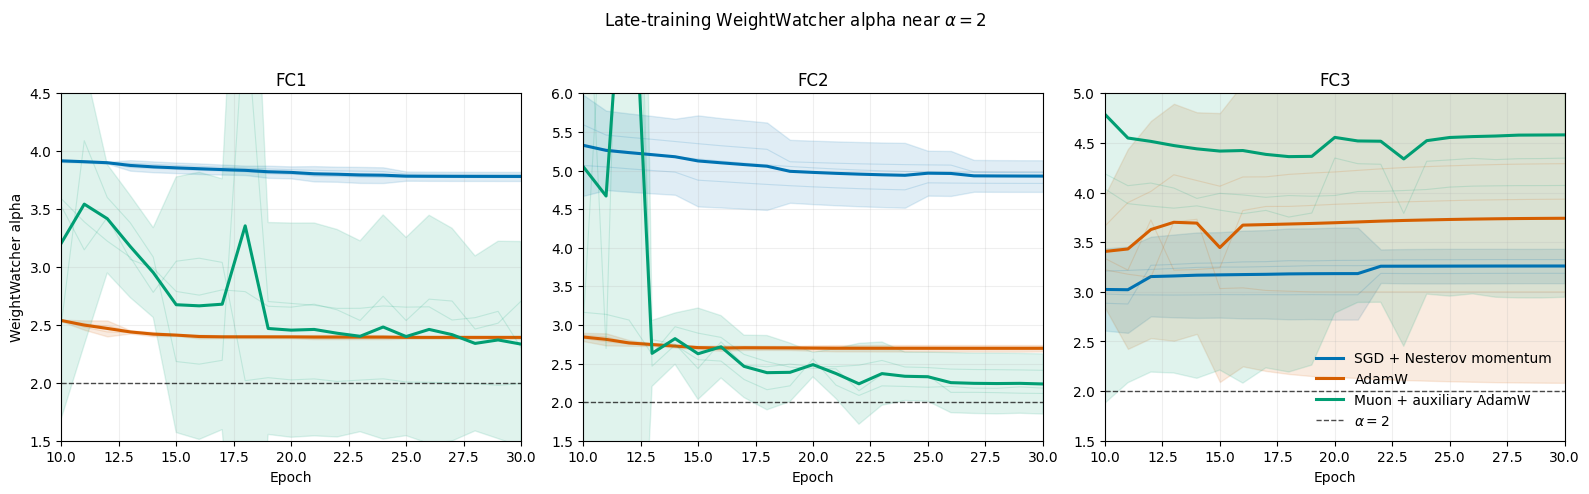

zoomed comparison plots: /private/tmp/rg_optimizers/baseline/notebooks/runs/mnist_mlp3_recipe_v3/comparison/plots/zoom_epoch_3_onward


In [3]:
ZOOM_START_EPOCH = 3
ALPHA_DETAIL_START_EPOCH = 10
ZOOM_PLOT_DIR = OUTPUT_DIR / 'plots' / f'zoom_epoch_{ZOOM_START_EPOCH}_onward'
ZOOM_PLOT_DIR.mkdir(parents=True, exist_ok=True)

performance_zoom = result.performance.loc[
    result.performance['epoch'].astype(int).ge(ZOOM_START_EPOCH)
].copy()
performance_summary_zoom = result.performance_summary.loc[
    result.performance_summary['epoch'].astype(int).ge(ZOOM_START_EPOCH)
].copy()
spectral_zoom = result.spectral_metrics.loc[
    result.spectral_metrics['epoch'].astype(int).ge(ZOOM_START_EPOCH)
].copy()
spectral_summary_zoom = result.spectral_summary.loc[
    result.spectral_summary['epoch'].astype(int).ge(ZOOM_START_EPOCH)
].copy()

zoom_plot_paths = []

for metric, ylabel, filename, reference, percent in PERFORMANCE_PLOTS:
    if metric not in performance_zoom.columns:
        continue
    if not performance_zoom[metric].notna().any():
        continue
    zoom_plot_paths.append(
        plot_performance_metric(
            performance_zoom,
            performance_summary_zoom,
            metric=metric,
            ylabel=ylabel,
            path=ZOOM_PLOT_DIR / filename,
            seeds=result.seeds,
            optimizer_order=OPTIMIZER_ORDER,
            labels=OPTIMIZER_LABELS,
            colors=OPTIMIZER_COLORS,
            horizontal_reference=reference,
            percent=percent,
            show=True,
        )
    )

for metric, ylabel, filename, reference in SPECTRAL_PLOTS:
    if metric == 'alpha':
        continue
    if metric not in spectral_zoom.columns:
        continue
    zoom_plot_paths.append(
        plot_spectral_metric(
            spectral_zoom,
            spectral_summary_zoom,
            metric=metric,
            ylabel=ylabel,
            path=ZOOM_PLOT_DIR / filename,
            seeds=result.seeds,
            optimizer_order=OPTIMIZER_ORDER,
            layer_order=LAYER_ORDER,
            labels=OPTIMIZER_LABELS,
            colors=OPTIMIZER_COLORS,
            horizontal_reference=reference,
            show=True,
        )
    )


def plot_bounded_alpha(
    *,
    start_epoch,
    y_limits_by_layer,
    title,
    filename,
):
    figure, axes = plt.subplots(
        1,
        len(LAYER_ORDER),
        figsize=(16.0, 4.8),
        sharex=True,
    )
    if len(LAYER_ORDER) == 1:
        axes = [axes]

    for axis, layer in zip(axes, LAYER_ORDER, strict=True):
        for optimizer in OPTIMIZER_ORDER:
            raw = result.spectral_metrics.loc[
                result.spectral_metrics['optimizer'].eq(optimizer)
                & result.spectral_metrics['layer'].astype(str).eq(str(layer))
                & result.spectral_metrics['epoch'].astype(int).ge(start_epoch)
            ]
            for seed in result.seeds:
                rows = raw.loc[
                    raw['seed'].astype(int).eq(int(seed))
                ].sort_values('epoch')
                axis.plot(
                    rows['epoch'],
                    rows['alpha'],
                    color=OPTIMIZER_COLORS[optimizer],
                    linewidth=0.8,
                    alpha=0.15,
                )

            rows = result.spectral_summary.loc[
                result.spectral_summary['optimizer'].eq(optimizer)
                & result.spectral_summary['layer'].astype(str).eq(str(layer))
                & result.spectral_summary['metric'].eq('alpha')
                & result.spectral_summary['epoch'].astype(int).ge(start_epoch)
            ].sort_values('epoch')
            if rows.empty:
                continue
            x = rows['epoch'].astype(float).to_numpy()
            mean = rows['mean'].astype(float).to_numpy()
            low = rows['ci_low'].astype(float).to_numpy()
            high = rows['ci_high'].astype(float).to_numpy()
            axis.plot(
                x,
                mean,
                color=OPTIMIZER_COLORS[optimizer],
                linewidth=2.2,
                label=OPTIMIZER_LABELS[optimizer],
            )
            axis.fill_between(
                x,
                low,
                high,
                color=OPTIMIZER_COLORS[optimizer],
                alpha=0.12,
            )

        axis.axhline(
            2.0,
            color='black',
            linewidth=1.0,
            linestyle='--',
            alpha=0.7,
            label=r'$\alpha = 2$',
        )
        axis.set_xlim(start_epoch, result.epochs)
        axis.set_ylim(*y_limits_by_layer[layer])
        axis.set(title=str(layer).upper(), xlabel='Epoch')
        axis.grid(alpha=0.2)

    axes[0].set_ylabel('WeightWatcher alpha')
    axes[-1].legend(frameon=False, loc='best')
    figure.suptitle(title, y=1.02)
    figure.tight_layout()
    path = ZOOM_PLOT_DIR / filename
    figure.savefig(path, dpi=180, bbox_inches='tight')
    plt.show()
    plt.close(figure)
    return path


post_transient_alpha_path = plot_bounded_alpha(
    start_epoch=ZOOM_START_EPOCH,
    y_limits_by_layer={
        'fc1': (1.5, 10.0),
        'fc2': (1.5, 10.0),
        'fc3': (2.0, 7.5),
    },
    title='WeightWatcher alpha after the initial transient',
    filename='20_weightwatcher_alpha_95ci_bounded.png',
)
zoom_plot_paths.append(post_transient_alpha_path)

alpha_near_two_path = plot_bounded_alpha(
    start_epoch=ALPHA_DETAIL_START_EPOCH,
    y_limits_by_layer={
        'fc1': (1.5, 4.5),
        'fc2': (1.5, 6.0),
        'fc3': (1.5, 5.0),
    },
    title=r'Late-training WeightWatcher alpha near $\alpha = 2$',
    filename='20_weightwatcher_alpha_95ci_near_two.png',
)
zoom_plot_paths.append(alpha_near_two_path)

print('zoomed comparison plots:', ZOOM_PLOT_DIR)


## Final and validation-selected performance

The validation-selected table evaluates the protected test set only after the checkpoint epoch has been chosen from validation loss.


In [4]:
display(
    result.terminal_by_seed.sort_values(
        ['checkpoint', 'optimizer_label', 'seed']
    )
)
display(
    result.terminal_summary.sort_values(
        ['metric', 'checkpoint', 'optimizer_label']
    )
)
assert result.terminal_summary['n'].eq(3).all()


,run,optimizer,epoch,global_step,primary_lr,auxiliary_lr,train_loss,train_accuracy,train_examples_evaluated,validation_loss,validation_accuracy,validation_examples_evaluated,test_loss,test_accuracy,test_examples_evaluated,validation_loss_gap,test_loss_gap,validation_accuracy_gap,test_accuracy_gap,test_monitoring_only,online_train_loss,online_train_accuracy,mean_gradient_norm_before_clip,median_gradient_norm_before_clip,max_gradient_norm_before_clip,batches,parameter_l2_norm,train_time_sec,evaluation_time_sec,weightwatcher_time_sec,epoch_total_time_sec,device,seed,replicate,optimizer_label,train_perplexity,validation_perplexity,test_perplexity,checkpoint
0,AdamW,adamw,30,12900,0.000010,NaN,1.468589e-05,1.000000,55000,0.087420,0.9858,5000,0.077554,0.9852,10000,0.087406,0.077540,0.014200,0.014800,1,1.497354e-05,1.000000,7.106780e-04,5.965125e-04,0.004089,430,57.086986,4.533634,4.454976,2.531176,11.519786,mps,1337,0,AdamW,1.000015,1.091355,1.080641,final
2,AdamW,adamw,30,12900,0.000010,NaN,1.581340e-05,1.000000,55000,0.084746,0.9868,5000,0.084766,0.9855,10000,0.084730,0.084750,0.013200,0.014500,1,1.611085e-05,1.000000,7.548133e-04,6.386511e-04,0.003510,430,57.505001,4.586236,4.534660,2.700541,11.821437,mps,2027,1,AdamW,1.000016,1.088440,1.088462,final
4,AdamW,adamw,30,12900,0.000010,NaN,1.408119e-05,1.000000,55000,0.093397,0.9866,5000,0.085351,0.9847,10000,0.093383,0.085337,0.013400,0.015300,1,1.436087e-05,1.000000,6.935033e-04,5.724836e-04,0.006499,430,57.158256,4.536428,4.520927,7.431150,16.488505,mps,31415,2,AdamW,1.000014,1.097897,1.089100,final
12,Muon + auxiliary AdamW,sgd_momentum_muon,30,12900,0.002000,0.00003,3.467906e-11,1.000000,55000,0.136876,0.9868,5000,0.125038,0.9871,10000,0.136876,0.125038,0.013200,0.012900,1,1.907348e-10,1.000000,5.074270e-08,1.189849e-08,0.000001,430,85.310296,7.009080,4.612109,2.612202,14.233390,mps,1337,0,Muon + auxiliary AdamW,1.000000,1.146686,1.133191,final
14,Muon + auxiliary AdamW,sgd_momentum_muon,30,12900,0.002000,0.00003,8.019533e-11,1.000000,55000,0.121383,0.9892,5000,0.125831,0.9858,10000,0.121383,0.125831,0.010800,0.014200,1,2.969394e-10,1.000000,7.003446e-08,1.311741e-08,0.000003,430,84.935265,7.184085,5.215259,3.317289,15.716633,mps,2027,1,Muon + auxiliary AdamW,1.000000,1.129058,1.134090,final
16,Muon + auxiliary AdamW,sgd_momentum_muon,30,12900,0.002000,0.00003,6.068835e-11,1.000000,55000,0.131954,0.9902,5000,0.119270,0.9861,10000,0.131954,0.119270,0.009800,0.013900,1,2.167441e-10,1.000000,5.603925e-08,1.269139e-08,0.000001,430,85.070790,8.192268,5.311766,3.464090,16.968123,mps,31415,2,Muon + auxiliary AdamW,1.000000,1.141056,1.126674,final
6,SGD + Nesterov momentum,sgd_momentum,30,12900,0.000500,NaN,6.801713e-04,1.000000,55000,0.061781,0.9846,5000,0.059031,0.9841,10000,0.061101,0.058351,0.015400,0.015900,1,6.813720e-04,1.000000,2.169779e-02,1.987243e-02,0.063119,430,35.853322,4.329755,4.549400,3.660399,12.539553,mps,1337,0,SGD + Nesterov momentum,1.000680,1.063729,1.060808,final
8,SGD + Nesterov momentum,sgd_momentum,30,12900,0.000500,NaN,6.902663e-04,1.000000,55000,0.060265,0.9852,5000,0.055548,0.9848,10000,0.059575,0.054858,0.014800,0.015200,1,6.915217e-04,1.000000,2.195937e-02,2.086831e-02,0.065826,430,35.916103,4.326884,4.640553,2.583035,11.550472,mps,2027,1,SGD + Nesterov momentum,1.000691,1.062118,1.057120,final
10,SGD + Nesterov momentum,sgd_momentum,30,12900,0.000500,NaN,6.679502e-04,1.000000,55000,0.056884,0.9862,5000,0.055936,0.9836,10000,0.056216,0.055268,0.013800,0.016400,1,6.691356e-04,1.000000,2.131569e-02,2.023451e-02,0.080551,430,35.897569,4.595391,5.008348,3.166980,12.770719,mps,31415,2,SGD + Nesterov momentum,1.000668,1.058533,1.057530,final
1,AdamW,adamw,7,3010,0.000899,NaN,1.355872e-02,0.995255,55000,0.077829,0.9822,5000,0.072678,0.9808,10000,0.064270,0.059119,0.013055,0.014455,1,1.859848e-02,0.993891,3.865684e-01,3.435662e-01,1.228074,430,53.670736,4.723010,4.639184,2.870816,12.233010,mps,1337,0,AdamW,1.013651,1.080937,1.075384,validation_selected


,optimizer,optimizer_label,checkpoint,metric,n,mean,std,sem,confidence,critical_value,ci_half_width,ci_low,ci_high,minimum,maximum
19,adamw,AdamW,final,epoch_total_time_sec,3,1.327658e+01,2.785698e+00,1.608323e+00,0.95,4.302653,6.920057e+00,6.356518e+00,2.019663e+01,1.151979e+01,1.648850e+01
99,sgd_momentum_muon,Muon + auxiliary AdamW,final,epoch_total_time_sec,3,1.563938e+01,1.369002e+00,7.903938e-01,0.95,4.302653,3.400790e+00,1.223859e+01,1.904017e+01,1.423339e+01,1.696812e+01
59,sgd_momentum,SGD + Nesterov momentum,final,epoch_total_time_sec,3,1.228691e+01,6.481672e-01,3.742195e-01,0.95,4.302653,1.610137e+00,1.067678e+01,1.389705e+01,1.155047e+01,1.277072e+01
39,adamw,AdamW,validation_selected,epoch_total_time_sec,3,1.224449e+01,3.327057e-01,1.920877e-01,0.95,4.302653,8.264867e-01,1.141801e+01,1.307098e+01,1.191768e+01,1.258279e+01
119,sgd_momentum_muon,Muon + auxiliary AdamW,validation_selected,epoch_total_time_sec,3,1.595952e+01,1.418347e+00,8.188832e-01,0.95,4.302653,3.523370e+00,1.243615e+01,1.948289e+01,1.432237e+01,1.681686e+01
79,sgd_momentum,SGD + Nesterov momentum,validation_selected,epoch_total_time_sec,3,1.198678e+01,6.803599e-01,3.928060e-01,0.95,4.302653,1.690108e+00,1.029667e+01,1.367688e+01,1.155047e+01,1.277072e+01
17,adamw,AdamW,final,evaluation_time_sec,3,4.503521e+00,4.259808e-02,2.459402e-02,0.95,4.302653,1.058195e-01,4.397701e+00,4.609340e+00,4.454976e+00,4.534660e+00
97,sgd_momentum_muon,Muon + auxiliary AdamW,final,evaluation_time_sec,3,5.046378e+00,3.791709e-01,2.189144e-01,0.95,4.302653,9.419127e-01,4.104465e+00,5.988290e+00,4.612109e+00,5.311766e+00
57,sgd_momentum,SGD + Nesterov momentum,final,evaluation_time_sec,3,4.732767e+00,2.429732e-01,1.402806e-01,0.95,4.302653,6.035788e-01,4.129188e+00,5.336345e+00,4.549400e+00,5.008348e+00
37,adamw,AdamW,validation_selected,evaluation_time_sec,3,4.630966e+00,7.236739e-02,4.178133e-02,0.95,4.302653,1.797706e-01,4.451196e+00,4.810737e+00,4.554841e+00,4.698874e+00


## Validation convergence and matched-seed contrasts

Convergence thresholds are defined on validation accuracy. Paired differences are reported for both final and validation-selected checkpoints.


In [5]:
display(result.convergence_by_seed.sort_values(['optimizer_label', 'seed']))
display(result.convergence_summary.sort_values(['metric', 'optimizer_label']))
display(
    result.paired_final_differences.sort_values(
        ['checkpoint', 'metric', 'contrast']
    )
)


,optimizer,optimizer_label,seed,best_validation_loss,best_validation_epoch,validation_selected_test_accuracy,validation_selected_test_loss,final_test_accuracy,final_test_loss,epoch_to_validation_accuracy_0.90,epoch_to_validation_accuracy_0.95,epoch_to_validation_accuracy_0.97,epoch_to_validation_accuracy_0.98
3,adamw,AdamW,1337,0.077829,7,0.9808,0.072678,0.9852,0.077554,1.0,2.0,4.0,7.0
4,adamw,AdamW,2027,0.078772,3,0.9762,0.078702,0.9855,0.084766,1.0,1.0,2.0,6.0
5,adamw,AdamW,31415,0.072267,10,0.9804,0.088287,0.9847,0.085351,1.0,1.0,2.0,7.0
6,sgd_momentum_muon,Muon + auxiliary AdamW,1337,0.090952,1,0.9734,0.088296,0.9871,0.125038,1.0,1.0,1.0,10.0
7,sgd_momentum_muon,Muon + auxiliary AdamW,2027,0.090363,1,0.9714,0.093771,0.9858,0.125831,1.0,1.0,1.0,15.0
8,sgd_momentum_muon,Muon + auxiliary AdamW,31415,0.091120,1,0.9704,0.093823,0.9861,0.119270,1.0,1.0,1.0,13.0
0,sgd_momentum,SGD + Nesterov momentum,1337,0.061764,25,0.9841,0.059087,0.9841,0.059031,1.0,1.0,3.0,6.0
1,sgd_momentum,SGD + Nesterov momentum,2027,0.060265,30,0.9848,0.055548,0.9848,0.055548,1.0,2.0,3.0,7.0
2,sgd_momentum,SGD + Nesterov momentum,31415,0.056884,30,0.9836,0.055936,0.9836,0.055936,1.0,1.0,3.0,7.0


,optimizer,optimizer_label,metric,n,mean,std,sem,confidence,critical_value,ci_half_width,ci_low,ci_high,minimum,maximum
1,adamw,AdamW,best_validation_epoch,3,6.666667,3.511885,2.027588,0.95,4.302653,8.724005,-2.057338,15.390672,3.000000,10.000000
21,sgd_momentum_muon,Muon + auxiliary AdamW,best_validation_epoch,3,1.000000,0.000000,0.000000,0.95,4.302653,0.000000,1.000000,1.000000,1.000000,1.000000
11,sgd_momentum,SGD + Nesterov momentum,best_validation_epoch,3,28.333333,2.886751,1.666667,0.95,4.302653,7.171088,21.162245,35.504421,25.000000,30.000000
0,adamw,AdamW,best_validation_loss,3,0.076289,0.003515,0.002029,0.95,4.302653,0.008732,0.067558,0.085021,0.072267,0.078772
20,sgd_momentum_muon,Muon + auxiliary AdamW,best_validation_loss,3,0.090812,0.000398,0.000230,0.95,4.302653,0.000988,0.089824,0.091800,0.090363,0.091120
10,sgd_momentum,SGD + Nesterov momentum,best_validation_loss,3,0.059637,0.002500,0.001443,0.95,4.302653,0.006210,0.053427,0.065847,0.056884,0.061764
6,adamw,AdamW,epoch_to_validation_accuracy_0.90,3,1.000000,0.000000,0.000000,0.95,4.302653,0.000000,1.000000,1.000000,1.000000,1.000000
26,sgd_momentum_muon,Muon + auxiliary AdamW,epoch_to_validation_accuracy_0.90,3,1.000000,0.000000,0.000000,0.95,4.302653,0.000000,1.000000,1.000000,1.000000,1.000000
16,sgd_momentum,SGD + Nesterov momentum,epoch_to_validation_accuracy_0.90,3,1.000000,0.000000,0.000000,0.95,4.302653,0.000000,1.000000,1.000000,1.000000,1.000000
7,adamw,AdamW,epoch_to_validation_accuracy_0.95,3,1.333333,0.577350,0.333333,0.95,4.302653,1.434218,-0.100884,2.767551,1.000000,2.000000


,checkpoint,optimizer_a,optimizer_b,contrast,metric,n,mean_difference,std_difference,sem_difference,ci_half_width,ci_low,ci_high
0,final,adamw,sgd_momentum,AdamW - SGD + Nesterov momentum,test_accuracy,3,0.000967,2.309401e-04,1.333333e-04,0.000574,0.000393,0.001540
16,final,sgd_momentum_muon,adamw,Muon + auxiliary AdamW - AdamW,test_accuracy,3,0.001200,8.185353e-04,4.725816e-04,0.002033,-0.000833,0.003233
8,final,sgd_momentum_muon,sgd_momentum,Muon + auxiliary AdamW - SGD + Nesterov momentum,test_accuracy,3,0.002167,1.040833e-03,6.009252e-04,0.002586,-0.000419,0.004752
6,final,adamw,sgd_momentum,AdamW - SGD + Nesterov momentum,test_accuracy_gap,3,-0.000967,2.309401e-04,1.333333e-04,0.000574,-0.001540,-0.000393
22,final,sgd_momentum_muon,adamw,Muon + auxiliary AdamW - AdamW,test_accuracy_gap,3,-0.001200,8.185353e-04,4.725816e-04,0.002033,-0.003233,0.000833
14,final,sgd_momentum_muon,sgd_momentum,Muon + auxiliary AdamW - SGD + Nesterov momentum,test_accuracy_gap,3,-0.002167,1.040833e-03,6.009252e-04,0.002586,-0.004752,0.000419
1,final,adamw,sgd_momentum,AdamW - SGD + Nesterov momentum,test_loss,3,0.025719,6.232311e-03,3.598227e-03,0.015482,0.010237,0.041201
17,final,sgd_momentum_muon,adamw,Muon + auxiliary AdamW - AdamW,test_loss,3,0.040822,6.785732e-03,3.917744e-03,0.016857,0.023966,0.057679
9,final,sgd_momentum_muon,sgd_momentum,Muon + auxiliary AdamW - SGD + Nesterov momentum,test_loss,3,0.066541,3.504816e-03,2.023506e-03,0.008706,0.057835,0.075248
7,final,adamw,sgd_momentum,AdamW - SGD + Nesterov momentum,test_loss_gap,3,0.026384,6.231391e-03,3.597695e-03,0.015480,0.010904,0.041863


## Layerwise WeightWatcher summary

`alpha`, `ERG_gap`, and randomized-MP `num_traps` are direct WeightWatcher outputs. Each layer is summarized across the three complete runs; layers are not treated as additional replicates.


In [6]:
spectral = result.spectral_summary[
    result.spectral_summary['metric'].isin([
        'alpha', 'ERG_gap', 'num_traps',
        'm_midpoint', 'trace_log_midpoint_per_eval',
    ])
].sort_values(['metric', 'optimizer_label', 'layer', 'epoch'])
assert spectral['n'].eq(3).all()
display(spectral)


,optimizer,optimizer_label,layer,epoch,metric,n,mean,std,sem,confidence,critical_value,ci_half_width,ci_low,ci_high,minimum,maximum
4,adamw,AdamW,fc1,0,ERG_gap,3,357.666667,27.682726,15.982629,0.95,4.302653,68.767704,288.898962,426.434371,332.000000,387.000000
24,adamw,AdamW,fc1,1,ERG_gap,3,371.000000,3.000000,1.732051,0.95,4.302653,7.452413,363.547587,378.452413,368.000000,374.000000
44,adamw,AdamW,fc1,2,ERG_gap,3,318.000000,1.000000,0.577350,0.95,4.302653,2.484138,315.515862,320.484138,317.000000,319.000000
64,adamw,AdamW,fc1,3,ERG_gap,3,284.333333,3.055050,1.763834,0.95,4.302653,7.589166,276.744167,291.922499,281.000000,287.000000
84,adamw,AdamW,fc1,4,ERG_gap,3,266.333333,4.041452,2.333333,0.95,4.302653,10.039523,256.293810,276.372856,262.000000,270.000000
104,adamw,AdamW,fc1,5,ERG_gap,3,247.000000,0.000000,0.000000,0.95,4.302653,0.000000,247.000000,247.000000,247.000000,247.000000
124,adamw,AdamW,fc1,6,ERG_gap,3,236.333333,3.214550,1.855921,0.95,4.302653,7.985386,228.347948,244.318719,234.000000,240.000000
144,adamw,AdamW,fc1,7,ERG_gap,3,223.666667,2.309401,1.333333,0.95,4.302653,5.736870,217.929796,229.403537,221.000000,225.000000
164,adamw,AdamW,fc1,8,ERG_gap,3,212.000000,1.000000,0.577350,0.95,4.302653,2.484138,209.515862,214.484138,211.000000,213.000000
184,adamw,AdamW,fc1,9,ERG_gap,3,202.666667,3.214550,1.855921,0.95,4.302653,7.985386,194.681281,210.652052,199.000000,205.000000


The historical result-directory key `sgd_momentum_muon` is retained only for compatibility. Its implementation and label are **Muon + auxiliary AdamW**. No test metric is used for learning-rate choice, checkpoint selection, or stopping.
